# Predicción de churn de clientes
# Matías Toro

# Parte 1 — Exploración y preparación de datos

### Carga y caracterización inicial (1.1)

In [1]:
pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7043 filas, 21 columnas

In [4]:
df.shape

(7043, 21)

Parece que no hay nulls. mucha cantidad de valores string. Quizás haya que pasarlos a números. Aún no decido cual modelo ocupar.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("Filas duplicadas por customerID:", df.duplicated(subset=["customerID"]).sum())

Filas duplicadas (todas las columnas): 0
Filas duplicadas por customerID: 0


In [7]:
for i in df.select_dtypes(include=["str"]).columns.drop("customerID"): #customerID fuera: son muchos valores únicos que no aportan nada al análisis
    lista = df[i].unique().tolist()
    print(f"{i}: {sorted(lista, key=len)}")


gender: ['Male', 'Female']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'Yes', 'No phone service']
InternetService: ['No', 'DSL', 'Fiber optic']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['No', 'Yes', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['One year', 'Two year', 'Month-to-month']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Mailed check', 'Electronic check', 'Credit card (automatic)', 'Bank transfer (automatic)']
TotalCharges: [' ', '97', '70', '44', '38', '55', '85', '19', '80', '20', '62', '76', '45', '21', '71', '25', '52', '81', '95', '24', '74', '56', '49', '94', '46', '63', '60', '35', '72', '86', '58', '73', '273', '531', '702', '865', '846', '889', '597', '417', '267', '413', '713', '941', '579'

### Problemas de calidad de datos y su tratamiento (1.2)

Corrijo ese espacio vacío en TotalCharges

In [8]:
vacio = df.loc[df["TotalCharges"] == " "]
pd.set_option("display.max_columns", None)
display(vacio)
print(f"Cantidad total de filas: ", len(vacio))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Cantidad total de filas:  11


In [9]:
print(f"Porcentaje de valores faltantes en la columna TotalCharges: ", round(len(vacio)/len(df)*100, 2), "%")

Porcentaje de valores faltantes en la columna TotalCharges:  0.16 %


Existen 11 registros que no poseen TotalCharges. Esto puede, lo más seguro, que el cliente no tiene ningún cargo. Es más probable debido a que todos estos clientes tienen Tenure = 0 (nuevo cliente). Dado esto me inclino a pensar que la ausencia de dato es 0.

Todos ellos con 0 meses de antiguedad

In [10]:
print(vacio['tenure'].unique())

[0]


Cambiaré todos los valores ' ' por '0' para continuar con el análisis. De todas formas esta intervención en el dataset no tendrá gran impacto en caso de estar errónea dado que solo afecta al 0.16%  de los registros. 

Con esta solución aún mantengo todas las demás filas que sí aportan valor real al futuro modelo.

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

Paso los str a numeros (los que corresponda)

In [12]:
df["TotalCharges"] = df["TotalCharges"].astype("float")

Me cuesta un poco leer esto. Mejor hago graficos de caja

In [13]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [14]:
datos_numericos = df.select_dtypes(include=["number"])

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
datos_normalizados = pd.DataFrame(
    scaler.fit_transform(datos_numericos),
    columns=datos_numericos.columns
)

Para tenure, MonthlyCharges y TotalCharges no parece haber outliers. Si se ve un sesgo negativo en MonthlyCharges y uno positivo en TotalCharges. Además, estos 2 ultimos, al estar mas o menos no superpuestos, podrían funcionar como información útil para el modelo (si se mantiene esa característica cuando los enfrente a la variable objetivo que revisaré despues). Veamos SeniorCitizen con más detalle

<Axes: >

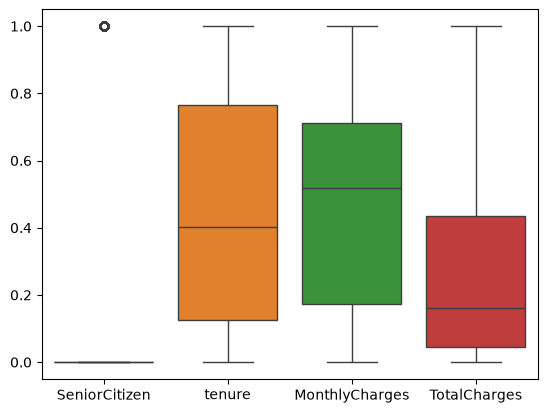

In [16]:
sns.boxplot(datos_normalizados)

Ah jfsakd Es binaria. lo transformo

<Axes: ylabel='SeniorCitizen'>

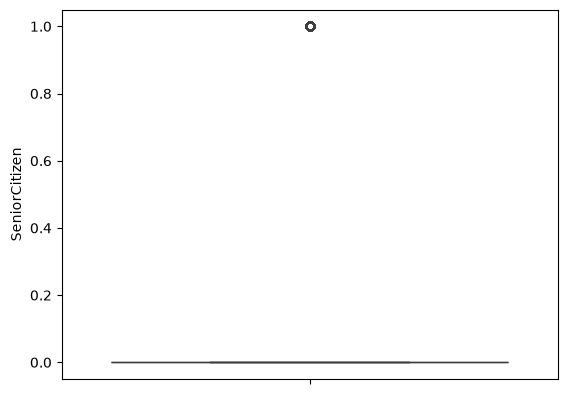

In [17]:
sns.boxplot(datos_numericos["SeniorCitizen"])

In [18]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype("boolean")

Reviso si hay valores faltantes en alguna de las columnas

In [19]:
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("Valores faltantes por columna:")
    print(missing_values[missing_values > 0])
    print("\nPorcentaje de valores faltantes por columna (solo > 0%):")
    print((missing_values[missing_values > 0] / len(df)) * 100)
else:
    print("No hay valores faltantes en ninguna columna")

No hay valores faltantes en ninguna columna


### Distribución de las variables y de la variable objetivo (1.1)

Veré como se distribuyen las demás columnas

In [20]:
columnas_str = df.select_dtypes(include=["object", "str"]).drop("customerID", axis=1)

In [21]:
columnas_str.nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64

Veo que hay mucha data redundante: Algunas columnas tienen dentro de sus variables "no internet" o "no phone service". Esto es redundante con la columna que indica si tiene o no internet o telefono.

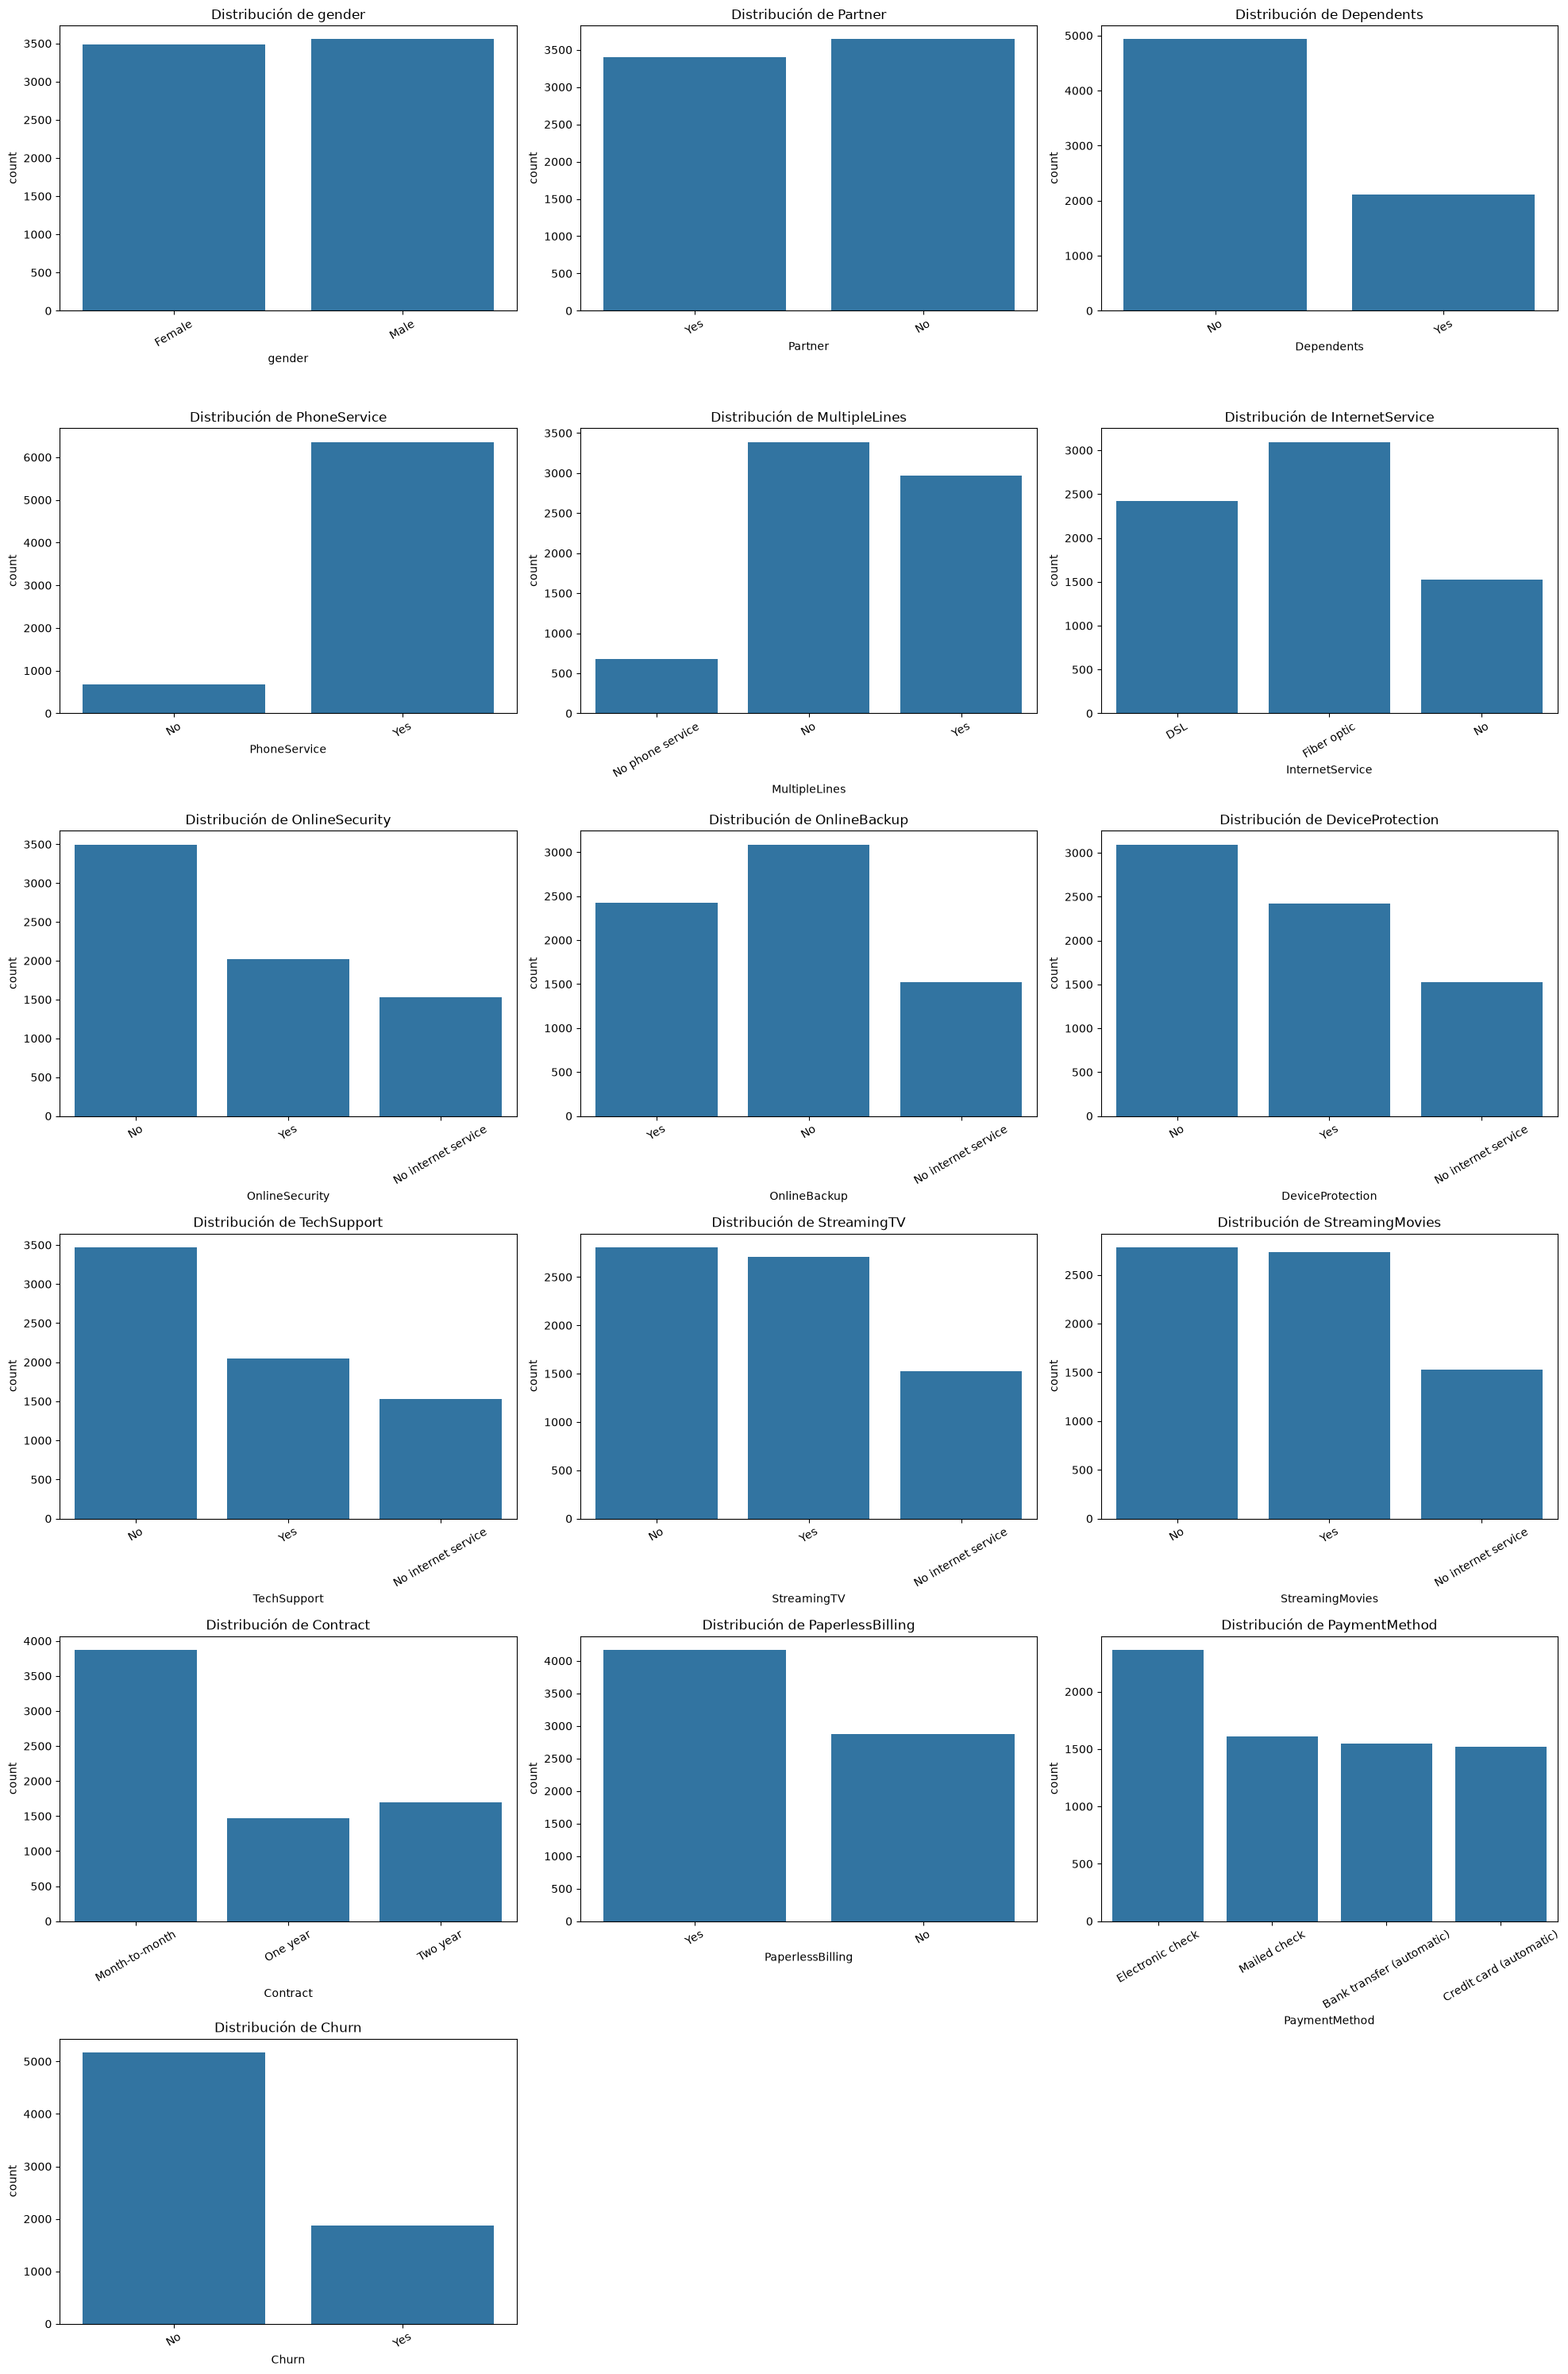

In [22]:
n_cols = 3
n_rows = -(-len(columnas_str.columns) // n_cols)  # división hacia arriba

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(columnas_str.columns):
    sns.countplot(data=columnas_str, x=col, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(columnas_str.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


La variable objetivo está bastante desbalanceada. habrá que asegurar una partición estratificada para el entrenamiento y testeo del modelo. ¿Quizás deba hacer over sampling?

o SMOTE quizás

Avanzaré con la relación original estratificando los datos. Luego de entrenar el modelo, si no me da buenos resultados, probaré con over sampling y SMOTE.

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str


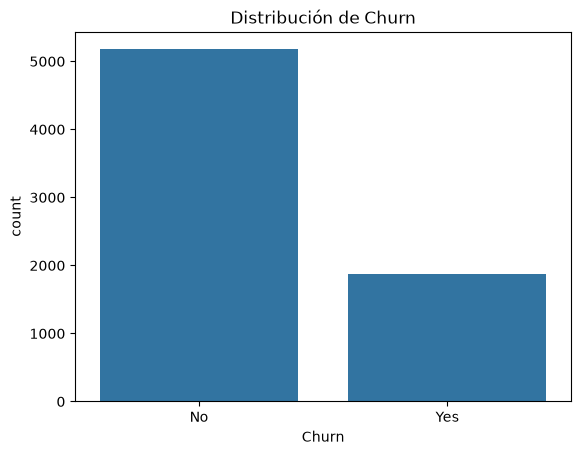

In [23]:
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

### Información redundante entre columnas (1.2)

Se me ocurre que quizás pueda colapsar algunas variables que tienen información redundante. Por ejemplo, si un cliente no tiene internet, no tiene sentido que tenga OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV y StreamingMovies. Lo mismo con MultipleLines y PhoneService.

Primero revisaré si los valores son efectivamente redundantes (si la columna de PhoneService [NO] y InternetService [NO] tienen los mismos valores que las columnas de MultipleLines y OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV y StreamingMovies respectivamente).

In [24]:
columnas_con_info_redundante = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]

for col in columnas_con_info_redundante:
    coincide = ((df[col] == "No internet service") == (df["InternetService"] == "No")).all()
    print(f"{col} coincide 100% con InternetService == 'No': {coincide}")

coincide_lines = ((df["MultipleLines"] == "No phone service") == (df["PhoneService"] == "No")).all()
print(f"MultipleLines coincide 100% con PhoneService == 'No': {coincide_lines}")


OnlineSecurity coincide 100% con InternetService == 'No': True
OnlineBackup coincide 100% con InternetService == 'No': True
DeviceProtection coincide 100% con InternetService == 'No': True
TechSupport coincide 100% con InternetService == 'No': True
StreamingTV coincide 100% con InternetService == 'No': True
StreamingMovies coincide 100% con InternetService == 'No': True
MultipleLines coincide 100% con PhoneService == 'No': True


En efecto es información redundante. Colapsaré las columnas.

In [25]:
df[columnas_con_info_redundante] = df[columnas_con_info_redundante].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")


Así mejor. Cuando haga one hot encoding habrá menos columnas y el modelo será más simple (y confiable debido a que la información redundante puede engañar a algunos modelos haciendoles creer que cierta info es más valiosa al aparecer en más columnas)

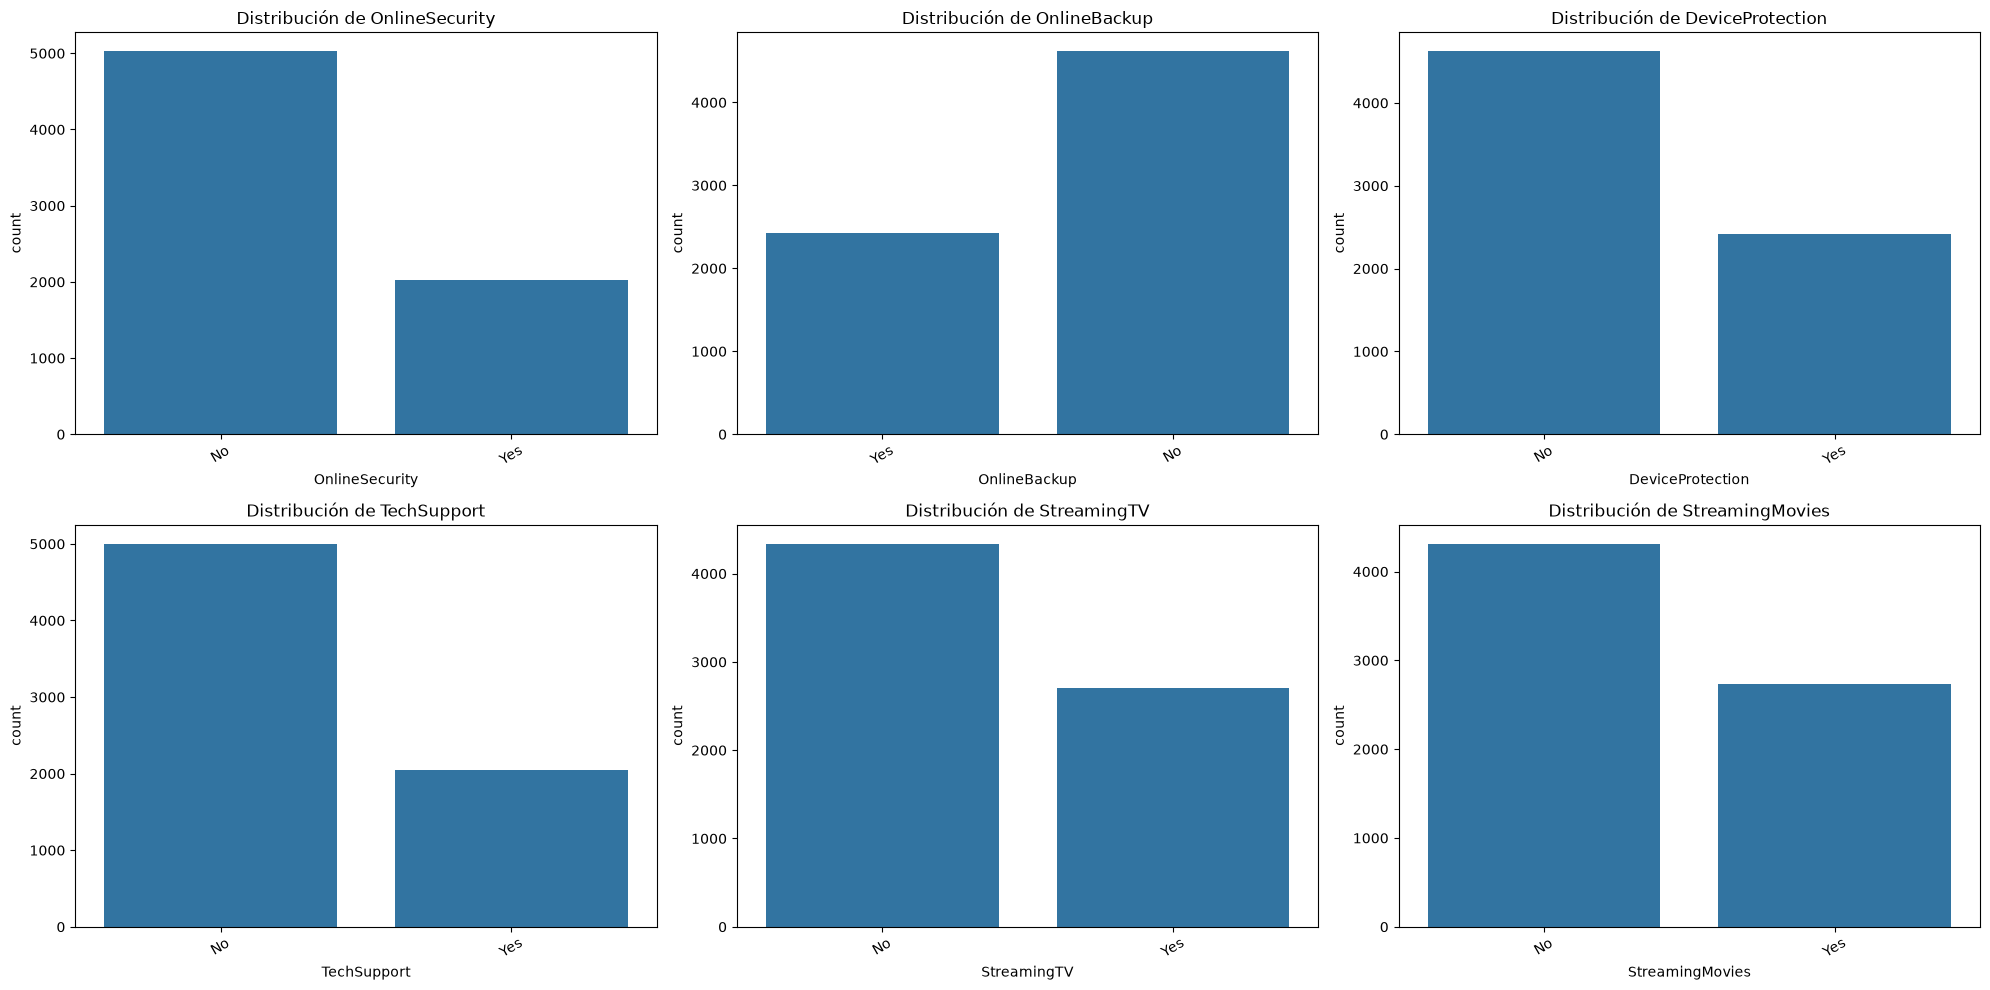

In [26]:
n_cols = 3
n_rows = -(-len(df[columnas_con_info_redundante].columns) // n_cols)  # división hacia arriba

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(columnas_con_info_redundante):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(columnas_con_info_redundante), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   boolean
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Codificación y escalamiento de variables (1.3)

Ahora puedo dejar más columnas en booleano. prefiero hacer esto porque con 2 categorías mutuamente excluyentes, un booleano capta toda la información en una sola columna. hacer one hot Encoding ahí generaría una columna redundante, igual que me pasó con las columnas de servicios

In [28]:
columnas_bool = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Churn"]

df[columnas_bool] = df[columnas_bool].apply(lambda col: col.map({"Yes": True, "No": False}))
df[columnas_bool] = df[columnas_bool].astype("boolean")

# gender no es Yes/No, así que va aparte
df["gender"] = df["gender"].map({"Male": True, "Female": False}).astype("boolean")


Escalaré las variables numéricas pero primero debo separarlas en train/test. De lo contrario, los parámetros de escalados se verían afectados por el conjuntos de test y eso sería dataleakage (el modelo aprendería a escalar los datos con datos que, en teoría, no debería conocer).

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding para las nominales que no tienen datos binarios o jerarquicos.
nominal_cols = ["InternetService", "PaymentMethod", "Contract"]
df_model = pd.get_dummies(df, columns=nominal_cols, drop_first=True)#Esto es lo que había visto de que si el modelo conoce n-1 columnas, la última la deduce solo sin revisar todo el df de nuevo y sin aportar info redundante

# Armo X e y (customerID fuera porque no aporta información, Churn es la variable objetivo)
X = df_model.drop(columns=["customerID", "Churn"])
y = df_model["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42 #aplicada la estratificación
)

# Escalo solo las numéricas. El scaler se ajusta (fit) únicamente con el train
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler() #las variables bool no necesitan escalarse
#ocupo standarscaler debido a que no hay outliers en las variables.

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


### Visualizaciones de variables vs Churn (1.4)

Compararé algunas variables con la variable objetivo.

Primero estudiaré la distribución de las variables categóricas no booleanas con respecto a la variable objetivo.

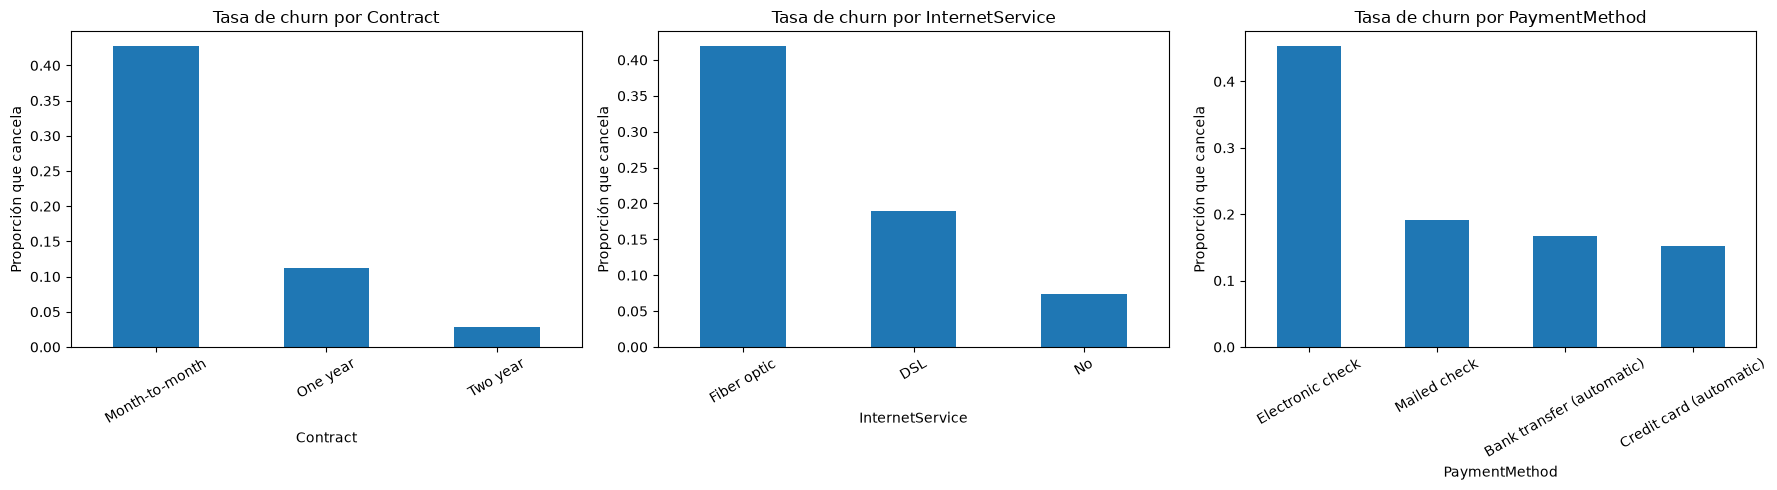

In [30]:
cat_cols_negocio = ["Contract", "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(1, len(cat_cols_negocio), figsize=(18, 5))

for ax, col in zip(axes, cat_cols_negocio):
    tasa = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    tasa.plot(kind="bar", ax=ax)
    ax.set_title(f"Tasa de churn por {col}")
    ax.set_ylabel("Proporción que cancela")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


>En las siguientes celdas trato de explicar por qué ciertas variables tienen más churn que otras. Sin embargo aclaro que estos análisis vienen de experiencia previa dentro del dominio del negocio (que no es mucha). Las teorías que propongo están limitadas a mi entendimiento del negocio. Por lo tanto puede ser que pierda relaciones importantes por no saber "donde buscar". 

>Podría mejorar mucho estos análisis si tuviera más conocimiento o, en mayor medida, tiempo para revisar el datasets y sus relaciones.

Se observa que las personas que más cancelan son:
1. Las que tienen contrato mensual (Esto es lógico. No hay compromiso de permanencia y puede que hayan estado pocos meses con la empresa. es más esperable que se vaya una persona que no le gustó el servicio en sus primeros meses.) -> Revisaré esta teoría con la variable tenure.

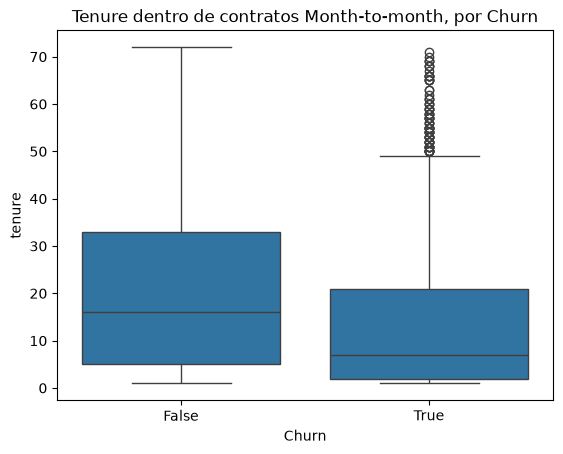

In [31]:
mtm = df[df["Contract"] == "Month-to-month"]

sns.boxplot(x="Churn", y="tenure", data=mtm)
plt.title("Tenure dentro de contratos Month-to-month, por Churn")
plt.show()


Los datos apoyan la teoría. De las personas que tienen contrato mensual, es más probable que se vayan en sus primeros meses: el contrato month to month les da la libertad de irse apenas el servicio no los convence, sin costo de salida. De todas formas, con estos datos no puedo separar cuánto pesa la libertad del contrato y cuánto el simple hecho de ser un cliente nuevo.

Se observa que las personas que más cancelan son:

2. Las personas con servicio contratado de fibra óptica. Esto podría deberse al precio de la fibra óptica (la competencia de la fibra es elevada pero tambien lo es la del servicio movil). Revisaré esta teoría con la variable MonthlyCharges.

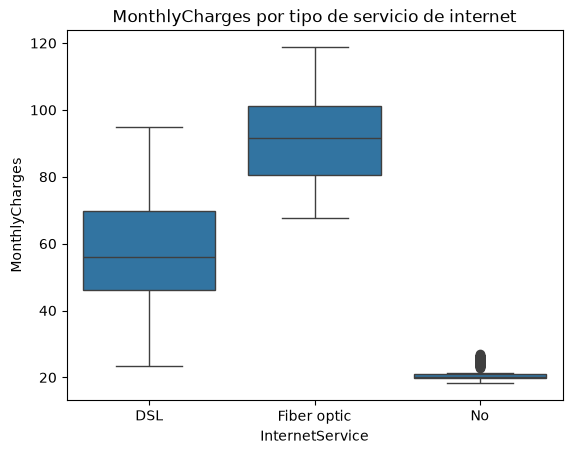

                      mean  median
InternetService                   
DSL              58.102169  56.150
Fiber optic      91.500129  91.675
No               21.079194  20.150


In [32]:
sns.boxplot(x="InternetService", y="MonthlyCharges", data=df)
plt.title("MonthlyCharges por tipo de servicio de internet")
plt.show()

print(df.groupby("InternetService")["MonthlyCharges"].agg(["mean", "median"]))


Los datos apoyan la teoría: las personas con servicio de fibra óptica pagan más que las personas con DSL o sin internet. Esto podría explicar la mayor tasa de cancelación en este grupo, aunque es una correlación y no una causa comprobada (tambien podrían influir la calidad del servicio o la fuerte competencia en el mercado de la fibra).

Se observa que las personas que más cancelan son:

3. Personas que pagan con cheque electrónico. Esto podría deberse a una diferencia etaria entre los consumidores. Lo revisaré con la variable SeniorCitizen.

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: Float64


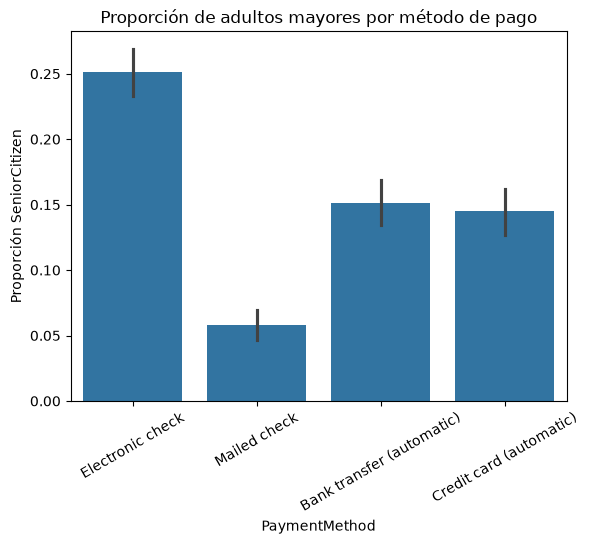

PaymentMethod
Electronic check             0.251163
Bank transfer (automatic)    0.150907
Credit card (automatic)      0.145204
Mailed check                 0.058313
Name: SeniorCitizen, dtype: Float64


In [33]:
print(df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False))

sns.barplot(x="PaymentMethod", y="SeniorCitizen", data=df)
plt.title("Proporción de adultos mayores por método de pago")
plt.xticks(rotation=30)
plt.ylabel("Proporción SeniorCitizen")
plt.show()

print(df.groupby("PaymentMethod")["SeniorCitizen"].mean().sort_values(ascending=False))

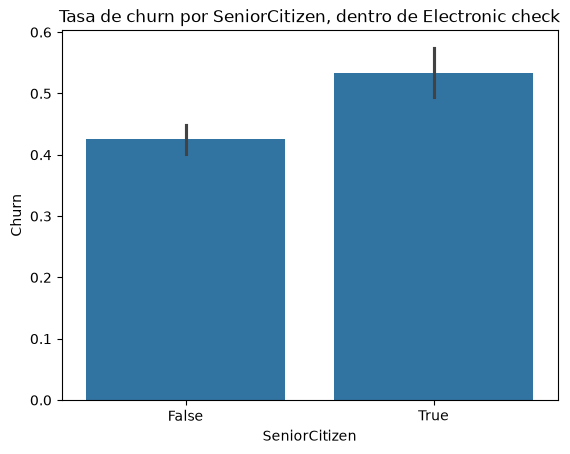

                   mean  count
SeniorCitizen                 
False          0.425748   1771
True            0.53367    594


In [34]:
# Dentro de Electronic check: ¿los seniors cancelan más que los no-seniors?
echeck = df[df["PaymentMethod"] == "Electronic check"]

sns.barplot(x="SeniorCitizen", y="Churn", data=echeck)
plt.title("Tasa de churn por SeniorCitizen, dentro de Electronic check")
plt.show()

print(echeck.groupby("SeniorCitizen")["Churn"].agg(["mean", "count"]))


Casi correcto. Las personas que pagan con cheque electrónico son en promedio más mayores que las que pagan con otro método pero el método de pago es un marcador de churn independiente de la edad; ser senior solo lo amplifica

Dentro de la variable ElectronicChek, los senior citizens cancelan más que las personas más jóvenes.

Hay otras dos relaciones que son interesantes.

al comparar tenure (meses como cliente de la empresa) con el churn se ve que las personas que llevan menos tiempo como clientes son más propensas a cancelar. Esto es lógico, tanto por lo que vi antes sobre los contratos month to month, como por la experiencia de que las personas que llevan poco tiempo como clientes aún no se han adaptado al servicio y es más probable que se vayan.
<br>Sin embargo se puede ver un grupito de outliers en el lado de "se van" que llevan más de 70 meses como clientes. Esto es interesante y me hace pensar que quizás haya un grupo de clientes que, por alguna razón, se van después de mucho tiempo como clientes. Quizas pueda ser un grupo de personas con comportamiento anormal.

Con respecto a los  MonthlyCharges, se ve que las personas que pagan más son más propensas a cancelar. Esto es acorde a análisis anteriores.

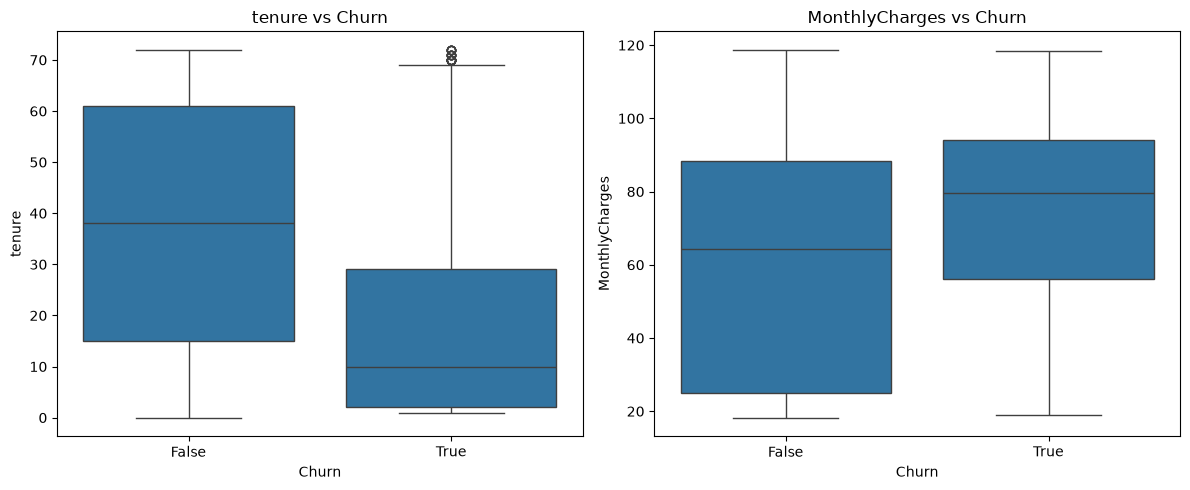

In [35]:
num_cols_negocio = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(1, len(num_cols_negocio), figsize=(12, 5))

for ax, col in zip(axes, num_cols_negocio):
    sns.boxplot(x="Churn", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()


Acá están los datos de los boxplots de Tenure. Se puede ver que, en general, las personas que se mantienen como clientes llevan, como mediana 38 meses. Comparando los 10 meses de los que sí se van, es evidente que las personas que llevan menos tiempo como clientes son más propensas a cancelar. incluso sus Q1 y Q3 están bastante alejados (mas de 7 veces el Q1 y el doble del Q3).<br>
Sobre el grupo de outliers que comentaba antes, son 23. Podría tratarse de un pequeño kernel de clientes que podría investigarse.

In [36]:
for churn_val in [False, True]:
    s = df.loc[df["Churn"] == churn_val, "tenure"]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"Churn={churn_val}: mediana={s.median():.0f}  Q1={q1:.0f}  Q3={q3:.0f}  outliers={outliers}")



Churn=False: mediana=38  Q1=15  Q3=61  outliers=0
Churn=True: mediana=10  Q1=2  Q3=29  outliers=23


Respecto a los que sí se van, acá hay un análisis más específico.<br>Mas la mitad de los que se van lo hacen no alcanza el año. Podría resultar interesante investigar técnicas de retención de clientes en sus primeros meses.

In [37]:
tasa_global = df["Churn"].mean() * 100
print(f"Tasa de churn global: {tasa_global:.1f}%\n")

for limite in [3, 6, 12]:
    sub = df[df["tenure"] <= limite]
    tasa = sub["Churn"].mean() * 100
    print(f"tenure <= {limite} meses: n={len(sub)}, tasa de churn = {tasa:.1f}%")


Tasa de churn global: 26.5%

tenure <= 3 meses: n=1062, tasa de churn = 56.2%
tenure <= 6 meses: n=1481, tasa de churn = 52.9%
tenure <= 12 meses: n=2186, tasa de churn = 47.4%


# Parte 2 — Modelo de clasificación

### Elección de modelos e hiperparámetros (2.1)

Para la parte de modelado usaré Regresión Logística y SVM.

¿Por qué Regresión logística?:
1. Es rápido de entrenar
2. Es interpretable (puedo ver qué variables son más importantes para el modelo)
3. Me entrega probabilidades de que un cliente se vaya, lo cual es útil para tomar decisiones de negocio (por ejemplo, si la probabilidad de que un cliente se vaya es mayor al 50%, puedo ofrecerle un descuento para retenerlo).

¿Por que SVM?:
1. Puede capturar relaciones no lineales entre las variables y la variable objetivo.
2. Es más robusto a outliers (Aunque en este caso no haya muchos, sigue siendo una ventaja)
3. Puede ser más preciso que la regresión logística en algunos casos, especialmente cuando las clases están desbalanceadas.

En este caso, el hiperparámetro C es el encargado de evitar que los pesos de las variables que use el modelo crezcan. No lo dejaré al azar y probaré varios.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

#StratifiedKFold para mantener la proporción de clases en cada fold, dado que el dataset está desbalanceado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #Usaré kfold para entrenar el modelo varias veces con distintos folds de entrenamiento y validación, y así obtener un resultado más robusto. No vaya a ser que justo justo el fold que use me dé resultados muy buenos o muy malos. Hay que evitar el sesgo.

#El shuffle sirve para que cada fold esté shuffleado. Así no se sesga el resultado si los datos están ordenados de alguna manera.

C_values = [0.01, 0.1, 1, 10, 100, 150, 200, 250, 300] #probaré varios c_values: Mientras más grande sea C, el modelo se ajusta más a los datos de entrenamiento. probaré estos y guardaré el que me de mejor resultado en ROC-AUC.
cv_scores = []

for C in C_values:
    modelo = LogisticRegression(C=C, class_weight="balanced", max_iter=1000, random_state=42)
    #EL class_weight="balanced" es para que el modelo tenga en cuenta el desbalance de clases y no se sesgue hacia la clase mayoritaria. Esto es importante porque si no lo hago, el modelo podría predecir siempre la clase mayoritaria y aún así tener una alta precisión, pero sería inútil para detectar la clase minoritaria (los clientes que se van).

    #max_iter es para que el modelo tenga más iteraciones para converger. Si no lo pongo, el modelo podría no converger y dar un warning. Puse 1000 porque es un número suficientemente grande para que el modelo converja, pero no tan grande como para que tarde mucho en entrenar. 100 tambien funcionaba pero 10 no. preferí no arriesgarme dado que el tiempo de computo no se disparaba.
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_scores.append(scores.mean())
    print(f"C={C}: ROC-AUC promedio (CV) = {scores.mean():.4f}")

mejor_C = C_values[cv_scores.index(max(cv_scores))]
print(f"\nMejor C: {mejor_C}")

#Acá el modelo se queda con el mejor C
log_reg = LogisticRegression(C=mejor_C, class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)


C=0.01: ROC-AUC promedio (CV) = 0.8417
C=0.1: ROC-AUC promedio (CV) = 0.8454
C=1: ROC-AUC promedio (CV) = 0.8459
C=10: ROC-AUC promedio (CV) = 0.8462
C=100: ROC-AUC promedio (CV) = 0.8462
C=150: ROC-AUC promedio (CV) = 0.8462
C=200: ROC-AUC promedio (CV) = 0.8462
C=250: ROC-AUC promedio (CV) = 0.8462
C=300: ROC-AUC promedio (CV) = 0.8462

Mejor C: 100


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

SVM tambien usa C como hiperparámetro (aunque aquí significa algo distinto) asi que seguí la misma lógica que con la regresión logística. Probaré varios valores de C y me quedaré con el que me de mejor resultado en ROC-AUC.

Qué es C?: Cuando SVM crea el hiperplano de separación que maximiza la distancia entre clases, tiene a C como parámetro que le indica qué tanto puede tolerar que un punto de una clase se encuentre en el espacio de otra.<br>Mientras más chico es C mayor es esa tolerancia.
<br> Un C más grande hace que la frontera se ajusto mucho más a cada punto de cada clase (puede resultar en mejores separaciones pero tambien puede haber overfitting. Dependerá del dataset y qué tan bien estén separadas las clases.)

In [39]:
from sklearn.svm import SVC

C_values_svm = [0.1, 1, 10, 20] #probaré varios c_values: es el peso que le da el modelo a cada variable. Mientras más grande sea C, el modelo se ajusta más a los datos de entrenamiento.
cv_scores_svm = []

for C in C_values_svm:
    modelo = SVC(C=C, kernel="rbf", gamma="scale", class_weight="balanced", random_state=42)
    #Usaré kernel rbf porque así SVM logra deformar la geometría del espacio para crear separaciones más complejas entre clases.
    #Gama define que tanta influencia tiene cada punto para definir a qué clase pertenece (similar a lo de los vecinos cercanos de KNN). el tamaño de gamma depende de que tan dispersos estén los datos. "scale" es para decirle al modelo que utilice la escala de los datos para calcular la influencia de cada punto.
    #class_weight="balanced" es para que el modelo tenga en cuenta el desbalance de clases y no se sesgue hacia la clase mayoritaria. Lo mismo que en LR.

    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_scores_svm.append(scores.mean())
    print(f"C={C}: ROC-AUC promedio (CV) = {scores.mean():.4f}")

mejor_C_svm = C_values_svm[cv_scores_svm.index(max(cv_scores_svm))]
print(f"\nMejor C: {mejor_C_svm}")

# probability=True solo en el modelo final (no durante la búsqueda) porque activa una
# calibración interna por CV que multiplica el tiempo de entrenamiento
svm_model = SVC(C=mejor_C_svm, kernel="rbf", gamma="scale", class_weight="balanced",
                probability=True, random_state=42)
#lo de probability=True es para que el modelo pueda dar probabilidades de pertenencia a cada clase, en lugar de solo la clase predicha. Esto lo hago para poder comparar este modelo con LR.
svm_model.fit(X_train, y_train)


C=0.1: ROC-AUC promedio (CV) = 0.8394
C=1: ROC-AUC promedio (CV) = 0.8291
C=10: ROC-AUC promedio (CV) = 0.8052
C=20: ROC-AUC promedio (CV) = 0.7961

Mejor C: 0.1


c:\Users\matin\Desktop\Codigos\Minería de datos\Tarea 2 Matias Toro\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Parece que hasta ahora gana Logistic Regression. Curioso (y beneficioso) que el modelo más simple e interpretable tenga un mejor resultado. Pero falta comparar resultados e impacto en el negocio.

### Estrategia de validación y manejo del desbalanceo (2.2)

Estrategia de validación utilizada:
- Hice un split 80/20 para modelar. Esto debido a que, en general, se busca un equilibrio entre tener suficientes datos de entrenamiento y suficientes datos para validar. Con 80% de los datos tengo (7043 * 0.8) 5634 registros para entrenar mi modelo lo cual, para este dataset específico, es suficiente gracias a la calidad de los datos. Además una vez hechas las pruebas obtengo un ROC-AUC de 84% (la probabilidad de que el modelo ordene a un churner por sobre un no-churner). Bastante alto.
- Usé estratificación con 5 folds para encontrar hiperparámetros (C en ambos casos). Se entrenaron 5 modelos (con 5 particiones distintas del set de entrenamiento) para cada C candidato. Hice esto para poder encontrar el mejor hiperparámetro para este dataset sin que mi poco dominio de los modelos influyera en el desempeño del mismo.
- Usé ROC-AUC en vez de métricas basadas en la matriz de confusión (como F1) porque estas últimas dependen de fijar un umbral de decisión (como si es 50% es churn), mientras que ROC-AUC evalúa qué tan bien el modelo ordena a los clientes por riesgo de churn en todos los umbrales posibles. Esto es más apropiado para elegir C, ya que aún no había decidido qué umbral usar para tomar decisiones de negocio (puede que en la empresa lo quieran cambiar de un momento a otro) y eso es especialmente útil por razones ya explicadas: <br>"Me entrega probabilidades de que un cliente se vaya, lo cual es útil para tomar decisiones de negocio (por ejemplo, si la probabilidad de que un cliente se vaya es mayor al 50%, puedo ofrecerle un descuento para retenerlo)."

Respecto al desbalanceo de la clase objetivo:
- Sí la consideré. En class_weight="balanced" en ambos modelos. Esto le sube el costo de equivocación en la clase minoritaria (el churn positivo).
- Había comentado al inicio del proyecto que cabía la posibilidad de usar SMOTE si los modelos no rendían bien debido a este desbalance. No hizo falta. Ambos modelos alcanzaron un ROC-AUC cercano a 84%.

### Comparación de métricas entre modelos (2.3)

Ya había dicho que para utilizar métricas diferentes a ROC-AUC debía fijar un umbral de decisión. Lo fijaré en *0.5* sobre las probabilidades (`predict_proba`) de ambos modelos.

> No uso `modelo.predict()` porque en SVM ese método clasifica según la distancia al hiperplano y no según la probabilidad calibrada, así que sus resultados no coincidirían con la curva ROC ni con la tabla de métricas (que sí usan probabilidades). En LR ambos caminos son equivalentes, pero prefiero que todo salga de la misma fuente.

De esta forma puedo hacer comparaciones de matriz de confusión, f1, precission, etc.

> Cabe destacar que, si en el futuro se cambia el umbral de decisión, habría que hacer nuevas comparaciones entre modelos

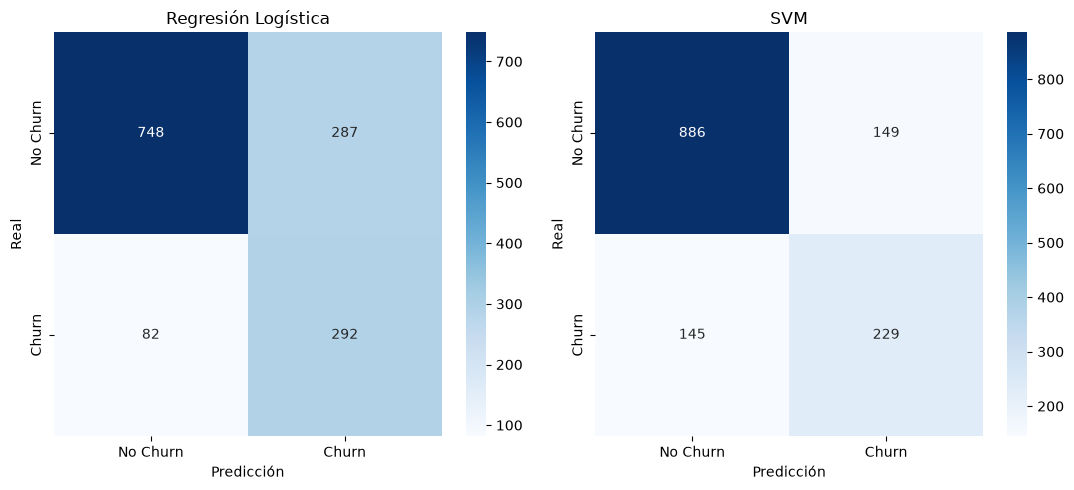

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

modelos = {
    "Regresión Logística": log_reg,
    "SVM":                 svm_model
}

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_prob = modelo.predict_proba(X_test)[:, 1] #uso las probabilidades y no modelo.predict() para que la matriz salga de la misma fuente que la tabla de métricas y la curva ROC
    y_pred = (y_prob >= 0.5).astype(int) #mismo umbral de 0.5 que en la tabla
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


In [41]:
filas = []
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    filas.append({
        "Modelo":    nombre,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob)
    })

tabla_metricas = pd.DataFrame(filas).set_index("Modelo").round(3)
display(tabla_metricas)


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Regresión Logística,0.738,0.504,0.781,0.613,0.840
SVM,0.791,0.606,0.612,0.609,0.836


Aquí ambas curvas superpuestas.

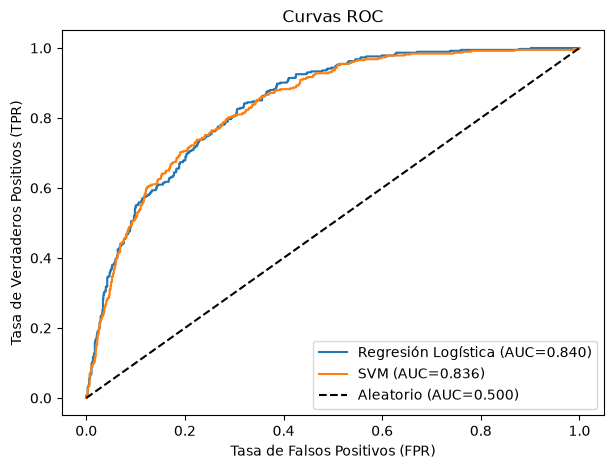

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC=0.500)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC")
ax.legend()
plt.show()


### Elección del modelo para NexoTel (2.4)

En el contexto de CHURN de una empresa de telecomunicaciones tengo unos parámetros para elegir el mejor modelo:
1. Un falso positivo indica que el modelo me dijo que X persona se va a ir. va a cancelar su contrato. Cuando, en realidad, no es así. La persona se quedará y puede que tampoco tenga intención de irse.
2. Un falso negativo indica que el modelo me dijo que X persona NO se va a ir pero, sin embargo, la persona sí tiene intención de irse o se irá en el tiempo próximo. Mi modelo falló al advertirme de su intención.
<br>
- Para el contexto entregado, considero que es peor un _*falso negativo*_ por las siguientes razones:
1. Mi modelo me dice que la persona *NO se irá*.<br>¿Qué ocurre? Me despreocupo.<br> Dejo de prestarle la atención  necesaria a esa persona y (más probablemente) se irá. Perder a un cliente siempre es mala noticia.
2. Cuesta más dinero, tiempo y recursos atraer nuevos clientes que mantener a los existentes. Si una persona abandona mi servicio me saldrá mucho más caro tratar de convencerla de que vuelva a mantenerla como cliente antes de que se vaya (debido a costos de marketing, promociones, visibilidad de marca, confianza con el público, etc.)
3. Un falso positivo podría presentar la siguiente situación:
- Le ofrezco planes, descuentos y atención especializada a una persona que no planeaba irse en primer lugar. <br> ¿Es tan grave?<br>No. No se gastan tantos recursos como si de recuperar al cliente se tratase y, en última instancia, puede que ese cliente reafirme su vinculo con la empresa al recibir trato preferente.

SVM a pesar de tener su probabilidad de que el modelo ordene un churner por sobre un no-churner casi igual a la de LR (83.6% < 84%), comete muchos más falsos negativos (145 > 82). Es LR quien minimiza el error que más me importa.

Cabe destacar que esta diferencia es grande (63 clientes de diferencia entre los falsos negativos: 63 churners reales que SVM dejaría escapar sin alerta) y puede escalar a cantidades aún más grandes si la empresa decide usar el modelo con miles y miles de clientes.

Tambien es importante mostrar que el accuracy de LR es un poco bajo (73.8%). Esto es esperable debido al desbalance de la clase objetivo y class_weight="balanced" (que hace que el modelo prefiera predecir churn a no hacerlo). El accuracy de SVM es más alto (79.1%) justamente porque su calibración de probabilidades atenúa ese efecto: predice churn menos veces, acierta más en la clase mayoritaria, pero deja escapar más churners. Lo importante aquí sin embargo es capturar churners reales a costa de falsos positivos.

Debido a todo esto debo recomendar el uso de **Regresión Logística**:

1. En la capacidad de ordenar clientes por riesgo (ROC-AUC) ambos modelos están practicamente empatados (84% vs 83.6%). No hay mayor diferencia entre ambos.
2. En el error más costoso para NexoTel (los falsos negativos) LR es claramente superior: deja escapar 82 churners contra los 145 de SVM.
3. Es el modelo más simple e interpretable de los dos. Puedo ver qué variables empujan el riesgo de cada cliente y explicárselo al equipo comercial.
4. Entrega probabilidades de forma directa, sin la calibración extra que necesita SVM. Eso permite mover el umbral de decisión según el presupuesto de retención (como dije antes, bajarlo para capturar más churners a costa de más falsas alarmas).

# Parte 3 — Análisis de clustering

### Selección de variables para el clustering (3.1)

K-means agrupa clientes según la distancia entre ellos. Si dos variables cuentan la misma historia (están muy correlacionadas), el modelo termina dándole el doble de peso a esa información sin querer. Por eso antes de aplicar K-means reviso qué variables son redundantes entre sí.

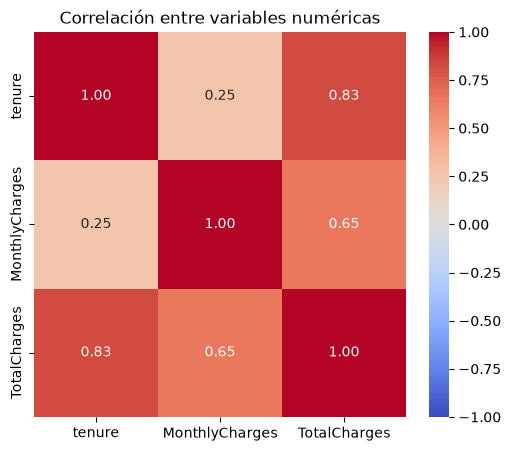

In [43]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()

`TotalCharges` está muy correlacionado con `tenure` (0.83) y con `MonthlyCharges` (0.65) — tiene sentido, porque `TotalCharges` es prácticamente el resultado acumulado de las otras dos (cliente antiguo que paga mucho, acumula más). No aporta información nueva, así que lo descarto del clustering y me quedo con `tenure` y `MonthlyCharges` por separado.

**Variables numéricas para K-means:** `tenure` (antigüedad del cliente) y `MonthlyCharges` (cuánto paga actualmente). Cada una cuenta una historia distinta del cliente.

Para las variables categóricas uso `Contract` e `InternetService`. fueron las dos con mayor asociación a `Churn` en mi EDA de la Parte 1, y representan dimensiones de negocio distintas: compromiso contractual y tipo de servicio contratado. Antes de aceptarlas reviso que no sean redundantes entre sí.

En un inicio había tomado otro enfoque para elegir qué variables agregar al K-MEANS: Pura estadística. Ocupé mucho tiempo y esfuerzo en hacer matrices de correlacion, cálculos ETA, ver qué grupos de variables podía reducir con PCA o con indicadores booleanos, ver qué variables me daban grupos más claros en k-means, etc. Al final desistí

Hacer todo ese análisis estadístico era
1. Muy dificil
2. Muy tardado
3. Y más importante, los resultados eran poco interpretables. K-Means me daba grupos que no tenían sentido lógico. Entendí que no es buena idea guiarme únicamente por análisis estadísticos ya que por mucho  que los números me dén correlaciones altas o bajas, de poco importa si no aplico criterio y dominio del negocio.
- Para facilitar el análisis me quedé con `Contract` e `InternetService` que cuentan historias diferentes y, además, ya vi previamente que tienen relación con la variable objetivo.

In [44]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(col1, col2):
    tabla = pd.crosstab(col1, col2)
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

v = cramers_v(df["Contract"], df["InternetService"])
print(f"Cramér's V entre Contract e InternetService: {v:.3f}")

Cramér's V entre Contract e InternetService: 0.207


Cramér's V = 0.207 = una asociación débil. `Contract` e `InternetService` no son redundantes entre sí, cada una aporta información distinta sobre el cliente.

**Variables finales para clustering:**
- Numéricas: `tenure`, `MonthlyCharges`
- Categóricas: `Contract`, `InternetService`
- Se descarta el resto de las variables (servicios adicionales, forma de pago, facturación, género, etc.) para mantener el clustering simple e interpretable. evitar que columnas muy correlacionadas entre sí (como los servicios de streaming/seguridad) le den más peso del debido a un mismo concepto al calcular distancias.
- `Churn` y `customerID` quedan fuera: `Churn` porque es lo que queremos explicar después con los clústeres, no una característica para agruparlos; `customerID` porque no aporta información real.
- escalaré `tenure` y `MonthlyCharges` con StandardScaler y codificaré `Contract`/`InternetService` con one hot Encoding, igual que en la Parte 2, pero esta vez sobre el dataset completo (no solo train), porque el objetivo es describir a todos los clientes actuales, no generalizar a datos nuevos.

Con todo esto que hice se pierde información sobre las variables que quedan fuera:
- ¿y si existe un grupo que contrata TV y gasta poco?
- ¿y si existe un grupo masculino que gasta harto en seguridad?


Sin embargo puedo responder esas preguntas más adelante de todas formas. Al revisar los clusters puedo entrar en el detalle de cada uno y ahí si reconocer a esos grupos.
<br><br> Este enfoque es más facil que el de hacer mucho más analisis estadístico y refinar al máximo la elección de variables para kmeans

Dataframe para el clustering (con escalado y one hot encoding):

Escalado estandar porque ya confirmé antes que no hay outliers en esas variables asi que uno no comprimirá el resto de datos.
La razón de escalar es debido a la naturaleza de kmeans que mide distancias. Una variable con valores muy altos podría opacar a otra variable con un rango de valores menor.

One hot encoding debido a que kmeans trabaja con números. no con valores categóricos.

In [45]:
cluster_cols = ["tenure", "MonthlyCharges", "Contract", "InternetService"]
df_cluster = df[cluster_cols].copy()

df_cluster = pd.get_dummies(df_cluster, columns=["Contract", "InternetService"])

scaler_cluster = StandardScaler()
df_cluster[["tenure", "MonthlyCharges"]] = scaler_cluster.fit_transform(df_cluster[["tenure", "MonthlyCharges"]])

df_cluster.head()


,tenure,MonthlyCharges,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,-1.277445,-1.160323,True,False,False,True,False,False
1,0.066327,-0.259629,False,True,False,True,False,False
2,-1.236724,-0.362660,True,False,False,True,False,False
3,0.514251,-0.746535,False,True,False,True,False,False
4,-1.236724,0.197365,True,False,False,False,True,False


### K-means: elección de k y evaluación con métricas internas (3.2)

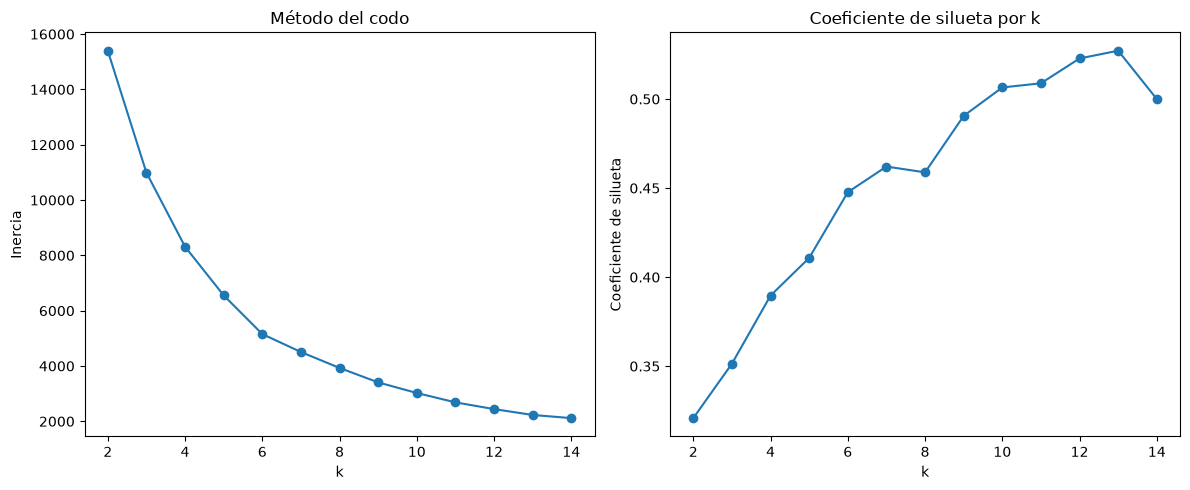

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
siluetas = []
rango_k = range(2, 15)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_cluster)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(df_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(rango_k, inercias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")

axes[1].plot(rango_k, siluetas, marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Coeficiente de silueta por k")

plt.tight_layout()
plt.show()


Análisis de gráficos

Veo que el codo se encuentra entre 5 y 8 K. me inclino a ocupar 6 para no tener demasiados clusters que luego podría ser dificil describir. Sobre el gráfico de coeficiente de silueta,que me dice qué tan lejos están los puntos de otros grupos y qué tan cerca lo están respecto a su propio grupo. Mientras mayor este valor, mejor. Este gráfico me dice que con 13 K los grupos quedan mejor definidos, sin embargo existe una meseta en 6-8 k,la que es bien similar a la información que me entregaba el gráfico de codo. prefiero dejar la interpretabilidad más sencilla y quedarme con K = 6.

In [47]:
from sklearn.metrics import davies_bouldin_score

kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(df_cluster)

sil_final = silhouette_score(df_cluster, df["cluster_kmeans"])
db_final = davies_bouldin_score(df_cluster, df["cluster_kmeans"])

print(f"Coeficiente de silueta (k=6): {sil_final:.4f}")
print(f"Davies-Bouldin (k=6): {db_final:.4f}")
print()
print("Tamaño de cada clúster:")
print(df["cluster_kmeans"].value_counts().sort_index())


Coeficiente de silueta (k=6): 0.4477
Davies-Bouldin (k=6): 0.9326

Tamaño de cada clúster:
cluster_kmeans
0     646
1    1317
2    1779
3     880
4    1341
5    1080
Name: count, dtype: int64


Los clusters quedaron con hartos datos cada uno. Podría ser señal de un análisis previo correcto.

El coeficiente de silueta de 0.4477 cae en la categoría de "Estructura debil" según Kaufman & Rousseeuw (creadores del método).

Esto dice que los clientes quedan categorizados mas o menos de forma deficiente. Esto no es necesariamente malo dado que las personas no se agrupan en grupos claramente definidos. Esto nos dice, sin embargo, que sí existe cierta separación en los perfiles.

Respecto a Davies-Bouldin (k=6): 0.9326 nos dice qué tan bien están separados los grupos entre sí. con un valor de 0.9326 (y considerando que 1 es el punto de equilibrio donde la dispersión interna empata a la separación de clusters).<br><br> considerando que este valor va de 0 a infinito un valor menor a 1 constituye una estructura base aceptable, confirmando que los grupos no están severamente solapados.

### Caracterización e interpretación de los clústeres (3.2)

In [48]:
#Caracterización de variables categóricas (proporción dentro de cada clúster)
print(pd.crosstab(df["cluster_kmeans"], df["Contract"], normalize="index").round(2))
print()
print(pd.crosstab(df["cluster_kmeans"], df["InternetService"], normalize="index").round(2))


Contract        Month-to-month  One year  Two year
cluster_kmeans                                    
0                         0.01      0.19      0.80
1                         0.30      0.38      0.32
2                         0.98      0.02      0.00
3                         0.59      0.27      0.14
4                         0.84      0.13      0.03
5                         0.09      0.37      0.54

InternetService  DSL  Fiber optic   No
cluster_kmeans                        
0                0.0          0.0  1.0
1                0.0          1.0  0.0
2                0.0          1.0  0.0
3                0.0          0.0  1.0
4                1.0          0.0  0.0
5                1.0          0.0  0.0


Aquí se extraen algunos análisis:

0. El cluster 0 se compone de personas que se han comprometido con 2 años de contrato y que no tienen servicio de internet.
1. El cluster 1 parece no tener mucha diferencia entre sus contratos pero que solo contratan fibra óptica.
2. el cluster 2 son personas con contrato a meses que solo contratan fibra óptica
3. el cluster 3 son personas que, en su mayoría tienen contrato a meses y que no tienen servicio de internet.
4. el cluster 4 se compone de personas que solo contratan DSL pero que llevan, en su mayoría, contrato a mes fijo.
5. el cluster 5 se compone de personas que solo contratan DSL y que se han comprometido con un tiempo más o menos grande en la empresa (más de la mitad de ellos con al menos dos años de contrato)

Se puede resumir así:

0. Contrato 2 años - Sin internet
1. *contratos de todo tipo* - Fibra
2. Contrato a mes  - Fibra
3. Contrato a mes  - Sin internet
4. Contrato a mes  - Solo DSL
5. Contrato 2 años - Solo DSL

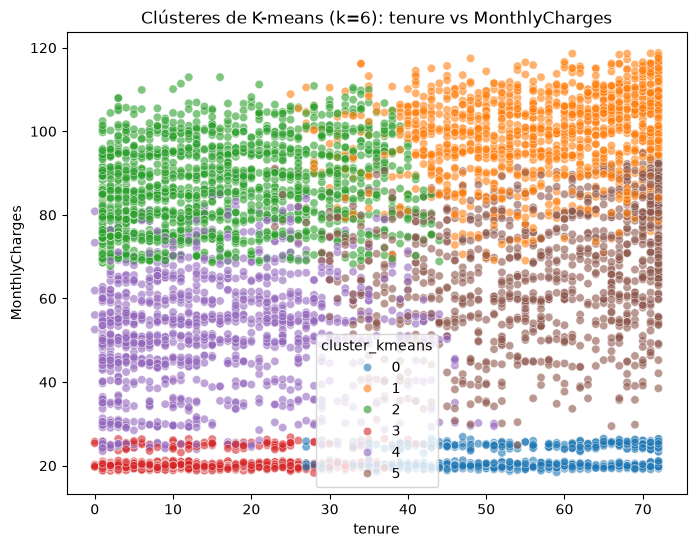

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="cluster_kmeans", palette="tab10", alpha=0.6)
plt.title("Clústeres de K-means (k=6): tenure vs MonthlyCharges")
plt.show()

Aquí se extraen algunos análisis:

0. El cluster 0 se compone de personas que llevan muchos meses en la empresa y tienen un gasto bajo.
1. El cluster 1 se compone de personas que llevan muchos meses en la empresa y tienen un gasto alto.
2. El cluster 2 se compone de personas que llevan pocos meses en la empresa y tienen un gasto alto.
3. El cluster 3 se compone de personas que llevan pocos meses en la empresa y tienen un gasto bajo.
4. El cluster 4 se compone de personas que llevan pocos meses en la empresa y tienen un gasto promedio.
5. El cluster 5 se compone de personas que llevan muchos meses en la empresa y tienen un gasto promedio.

Se puede resumir así:

0. Antigüedad alta - Gasto bajo
1. Antigüedad alta - Gasto alto
2. Antigüedad baja - Gasto alto
3. Antigüedad baja - Gasto bajo
4. Antigüedad baja - Gasto promedio
5. Antigüedad alta - Gasto promedio


Se puede resumir **todo** así:

0. Antigüedad alta - Gasto bajo     - Contrato 2 años   - Sin internet
1. Antigüedad alta - Gasto alto     - Contratos de todo tipo - Fibra
2. Antigüedad baja - Gasto alto     - Contrato a mes    - Fibra
3. Antigüedad baja - Gasto bajo     - Contrato a mes    - Sin internet
4. Antigüedad baja - Gasto promedio - Contrato a mes    - Solo DSL
5. Antigüedad alta - Gasto promedio - Contrato 2 años   - Solo DSL


Aquí un grafico para ver más claramente las agrupaciones dentro de cada tipo de contrato

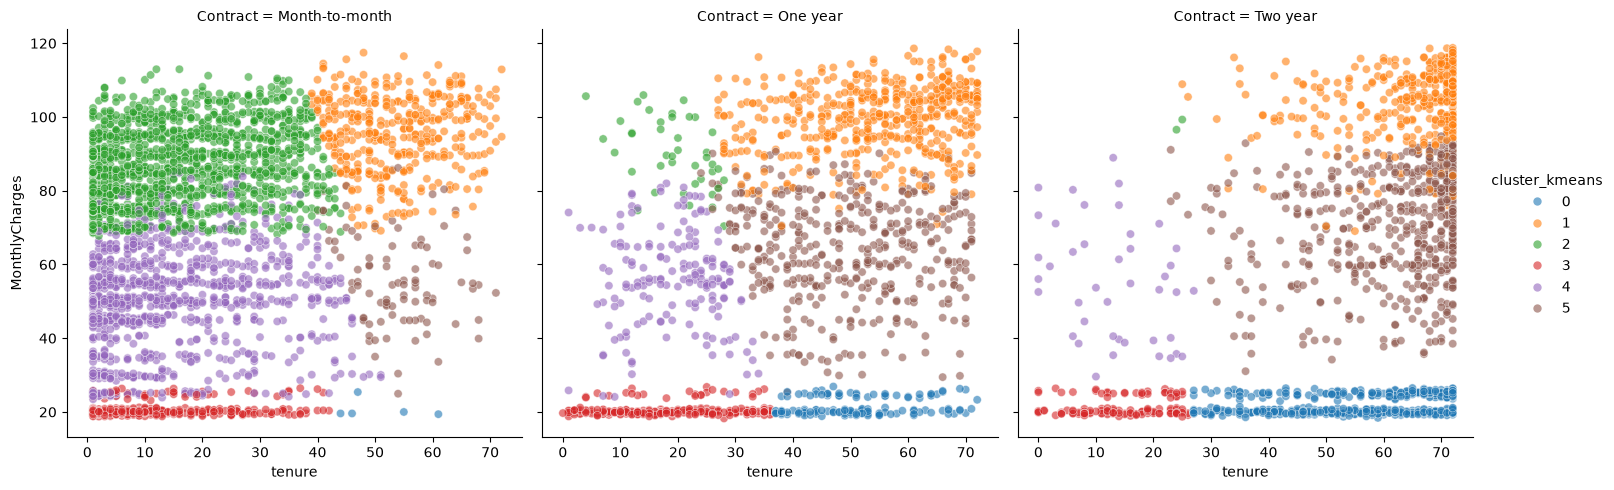

In [50]:
sns.relplot(
    data=df, x="tenure", y="MonthlyCharges",
    hue="cluster_kmeans", col="Contract",
    palette="tab10", alpha=0.6, height=5
)
plt.show()


Creo un gráfico 3d de 3 variables solo para ver como queda.

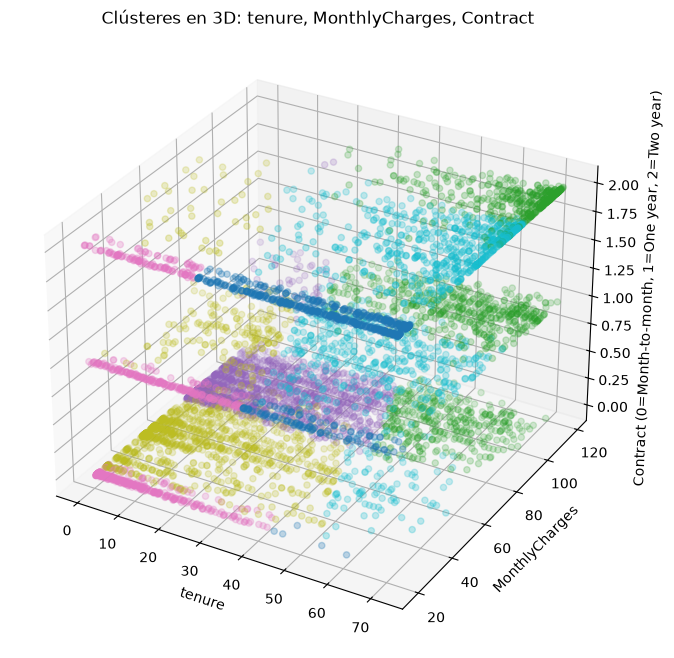

In [51]:
from mpl_toolkits.mplot3d import Axes3D

contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["contract_num"] = df["Contract"].map(contract_map)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["tenure"], df["MonthlyCharges"], df["contract_num"],
    c=df["cluster_kmeans"], cmap="tab10", alpha=0.6
)

ax.set_xlabel("tenure")
ax.set_ylabel("MonthlyCharges")
ax.set_zlabel("Contract (0=Month-to-month, 1=One year, 2=Two year)")
ax.set_title("Clústeres en 3D: tenure, MonthlyCharges, Contract")

plt.show()



Ahora reviso como cada grupo se comporta respecto al churn

In [52]:
print((df.groupby("cluster_kmeans")["Churn"].mean()*100).round(1)) #Porcentaje de churn


cluster_kmeans
0     1.2
1    19.6
2    58.4
3    11.9
4    29.9
5     5.4
Name: Churn, dtype: Float64


**Representación de clientes**:

0. "Leales sin internet" (646 clientes — el más pequeño)
Antigüedad alta con gasto bajo con contrato de 2 años, sin internet. Churn casi nulo (1.2%, el más bajo de todos). el segmento más fiel de la base pero gastan poco.

1. "Fibra premium fiel" (1317 clientes)
Antigüedad alta con gasto alto y varios tipos de contratos, Fibra óptica. Churn moderado (19.6%, bajo el promedio general). gastan harto y son relativamente estables.

2. "Fibra de alto riesgo" (1779 clientes — el más grande)
Antigüedad baja con gasto alto con contrato mes a mes, Fibra óptica. Churn muy alto (58.4%, más del doble del promedio). Estos clientes pagan mucho, son nuevos, y no tienen ningún compromiso contractual que los retenga. estos son los que más se van. se podría revisar porqué se van (quizas por insatisfaccion con el servicio o fuerte competencia).

3. "Nuevos sin internet" (880 clientes)
Antigüedad baja con gasto bajo con contrato mes a mes, sin internet. Churn bajo (11.9%), pese a no tener compromiso contractual. quizas sea porque el costo de cambiarse de proveedor no compensa para un plan tan básico.

4. "DSL nuevos sin compromiso" (1341 clientes)
Antigüedad baja con gasto promedio y contrato mes a mes, DSL. Churn por sobre el promedio (29.9%). clientes recientes con plan básico y sin atadura contractual.

5. "DSL fieles" (1080 clientes)
Antigüedad alta con un gasto promedio y contrato de 2 años, DSL. Churn muy bajo (5.4%). clientes fieles de larga data con compromiso contractual.

### DBSCAN (3.3)

DBSCAN agrupa según densidad: un punto es "núcleo" si tiene al menos `min_samples` vecinos dentro de un radio `eps`. Los núcleos conectados entre sí forman un cluster, y los puntos que no alcanzan la densidad de ningún grupo quedan como ruido (-1). A diferencia de K-means, no le digo cuántos grupos buscar (los encuentra solo) y además me señala explícitamente a los clientes que no calzan con ningún grupo. (como las x que habiamos visto en clases)<br><br> Uso el mismo `df_cluster` de K-means (mismas variables, mismo escalado y one hot encoding) para que la comparación sea igualitaria.
- Para `min_samples` uso la regla vista en clases de 2 × dimensiones. `df_cluster` tiene 8 columnas, así que `min_samples` = 16
- Para `eps` uso el gráfico de k-distancias: calculo la distancia de cada cliente a su vecino número 16, las ordeno y busco el codo donde la curva se dispara. Ese salto separa las distancias típicas dentro de zonas densas de las distancias de los puntos aislados

C:\Users\matin\AppData\Local\Temp\ipykernel_14980\2240737506.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


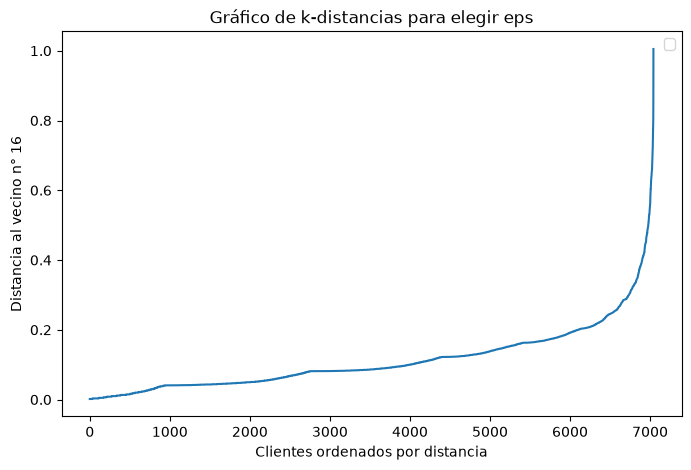

In [53]:
from sklearn.neighbors import NearestNeighbors

min_samples = 16

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(df_cluster)
distancias, _ = nn.kneighbors(df_cluster)

k_dist = np.sort(distancias[:, -1]) #distancia de cada punto a su vecino n16, ordenadas de menor a mayor

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel("Clientes ordenados por distancia")
plt.ylabel(f"Distancia al vecino n° {min_samples}")
plt.title("Gráfico de k-distancias para elegir eps")
plt.legend()
plt.show()


La curva se mantiene plana durante casi todo el recorrido, la gran mayoría de los clientes tiene a su vecino n° 16 a menos de 0.2 de distancia. Elijo eps = 0.30, justo después del quiebre

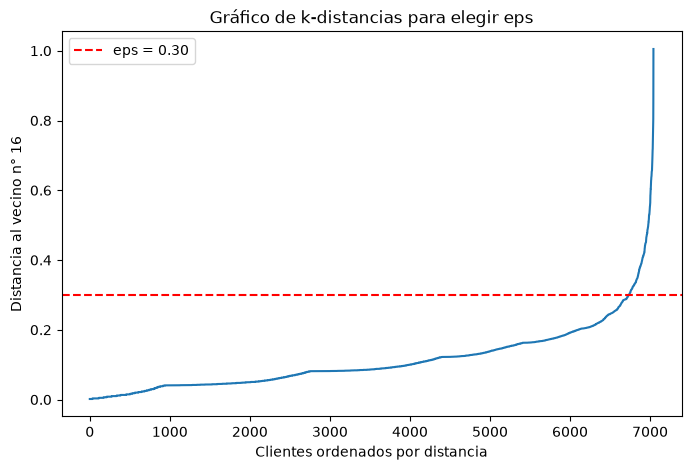

In [54]:
from sklearn.neighbors import NearestNeighbors

min_samples = 16

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(df_cluster)
distancias, _ = nn.kneighbors(df_cluster)

k_dist = np.sort(distancias[:, -1]) #distancia de cada punto a su vecino n16, ordenadas de menor a mayor

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.axhline(0.30, color="red", linestyle="--", label="eps = 0.30")
plt.xlabel("Clientes ordenados por distancia")
plt.ylabel(f"Distancia al vecino n° {min_samples}")
plt.title("Gráfico de k-distancias para elegir eps")
plt.legend()
plt.show()

Antes de quedarme con ese valor reviso qué tan sensible es el resultado a la elección:

In [55]:
from sklearn.cluster import DBSCAN

#Sensibilidad: muevo eps alrededor del codo para ver si la estructura cambia
for eps in [0.25, 0.30, 0.35]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(df_cluster)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_ru = (labels == -1).sum()
    print(f"eps={eps:.2f}: {n_cl} clusters, {n_ru} puntos de ruido")


eps=0.25: 9 clusters, 217 puntos de ruido
eps=0.30: 9 clusters, 132 puntos de ruido
eps=0.35: 9 clusters, 83 puntos de ruido


Con los tres valores DBSCAN encuentra los mismos **9 clusters** y solo cambia la cantidad de ruido (217, 132 y 83 puntos). La elección es robusta y además no estoy parado en una zona donde mover un poco eps cambie la estructura.

In [56]:
dbscan = DBSCAN(eps=0.30, min_samples=min_samples)
df["cluster_dbscan"] = dbscan.fit_predict(df_cluster)

n_clusters = df["cluster_dbscan"].nunique() - (1 if (df["cluster_dbscan"] == -1).any() else 0)
n_ruido = (df["cluster_dbscan"] == -1).sum()

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_ruido} ({n_ruido/len(df)*100:.1f}% de los clientes)")
print()
print("Tamaño de cada cluster (-1 = ruido):")
print(df["cluster_dbscan"].value_counts().sort_index())


Clusters encontrados: 9
Puntos de ruido: 132 (1.9% de los clientes)

Tamaño de cada cluster (-1 = ruido):
cluster_dbscan
-1     132
 0    1207
 1     559
 2    2128
 3     638
 4     528
 5     415
 6     364
 7     522
 8     550
Name: count, dtype: int64


9 clusters y 132 puntos de ruido (1.9%).

In [57]:
#Caracterización de variables categóricas (proporción dentro de cada clúster. -1 = ruido)
print(pd.crosstab(df["cluster_dbscan"], df["Contract"], normalize="index").round(2))
print()
print(pd.crosstab(df["cluster_dbscan"], df["InternetService"], normalize="index").round(2))


Contract        Month-to-month  One year  Two year
cluster_dbscan                                    
-1                        0.14      0.17       0.7
 0                        1.00      0.00       0.0
 1                        0.00      1.00       0.0
 2                        1.00      0.00       0.0
 3                        0.00      0.00       1.0
 4                        0.00      1.00       0.0
 5                        0.00      0.00       1.0
 6                        0.00      1.00       0.0
 7                        1.00      0.00       0.0
 8                        0.00      0.00       1.0

InternetService  DSL  Fiber optic    No
cluster_dbscan                         
-1               0.8         0.19  0.02
 0               1.0         0.00  0.00
 1               1.0         0.00  0.00
 2               0.0         1.00  0.00
 3               0.0         0.00  1.00
 4               0.0         1.00  0.00
 5               0.0         1.00  0.00
 6               0.0       

Aquí se extraen algunos análisis. A diferencia de K-means, cada cluster quedó 100% puro: una sola combinación de contrato × internet por grupo.

0. El cluster 0 se compone de personas con contrato a mes que solo contratan DSL.
1. el cluster 1 son personas con contrato de 1 año que solo contratan DSL.
2. el cluster 2 son personas con contrato a meses que solo contratan fibra óptica.
3. el cluster 3 son personas comprometidas a 2 años y sin servicio de internet.
4. el cluster 4 son personas con contrato de 1 año y fibra óptica.
5. el cluster 5 son personas comprometidas a 2 años con fibra óptica.
6. el cluster 6 son personas con contrato de 1 año y sin internet.
7. el cluster 7 son personas con contrato a meses y sin internet.
8. el cluster 8 son personas comprometidas a 2 años con DSL.

El ruido (-1) no tiene una combinación única: son 132 personas repartidas en varias combinaciones (la mayoría con contrato de 2 años y DSL).

Se puede resumir así:

0. Contrato a mes  - Solo DSL
1. Contrato 1 año  - Solo DSL
2. Contrato a mes  - Fibra
3. Contrato 2 años - Sin internet
4. Contrato 1 año  - Fibra
5. Contrato 2 años - Fibra
6. Contrato 1 año  - Sin internet
7. Contrato a mes  - Sin internet
8. Contrato 2 años - Solo DSL

-1. Ruido (mezcla de combinaciones)

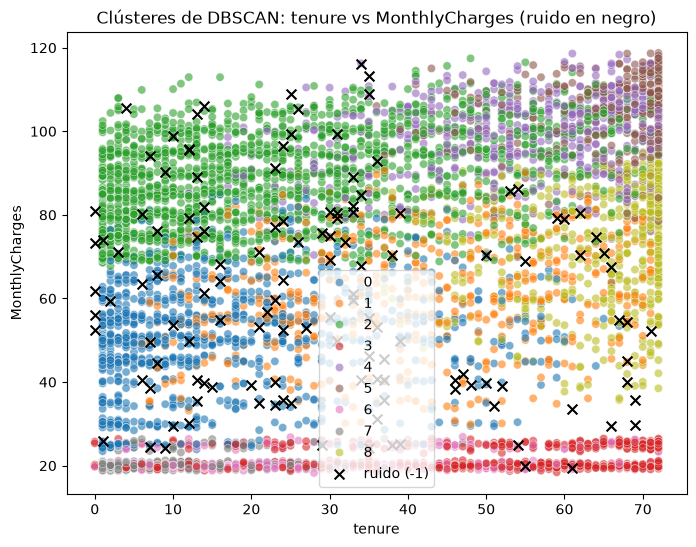

In [58]:
plt.figure(figsize=(8, 6))
ruido = df[df["cluster_dbscan"] == -1]
sns.scatterplot(data=df[df["cluster_dbscan"] != -1], x="tenure", y="MonthlyCharges", hue="cluster_dbscan", palette="tab10", alpha=0.6)
plt.scatter(ruido["tenure"], ruido["MonthlyCharges"], color="black", marker="x", s=50, label="ruido (-1)")
plt.title("Clústeres de DBSCAN: tenure vs MonthlyCharges (ruido en negro)")
plt.legend()
plt.show()


Aquí se extraen algunos análisis:

0. El cluster 0 se compone de personas que llevan pocos meses en la empresa y tienen un gasto promedio.
1. El cluster 1 se compone de personas que llevan un tiempo medio en la empresa y tienen un gasto promedio.
2. El cluster 2 se compone de personas que llevan pocos meses en la empresa y tienen un gasto alto.
3. El cluster 3 se compone de personas que llevan muchos meses en la empresa y tienen un gasto bajo.
4. El cluster 4 se compone de personas que llevan muchos meses en la empresa y tienen un gasto alto.
5. El cluster 5 se compone de personas que llevan muchos meses en la empresa y tienen el gasto más alto de todos.
6. El cluster 6 se compone de personas que llevan un tiempo medio en la empresa y tienen un gasto bajo.
7. El cluster 7 se compone de personas que llevan muy pocos meses en la empresa y tienen un gasto bajo.
8. El cluster 8 se compone de personas que llevan muchos meses en la empresa y tienen un gasto promedio.

El ruido (las X negras del gráfico) son personas que quedan lejos del comportamiento típico de su combinación: por ejemplo contratos de 2 años con muy poca antigüedad, o contratos a mes con muchísima antigüedad.

Se puede resumir así:

0. Antigüedad baja  - Gasto promedio
1. Antigüedad media - Gasto promedio
2. Antigüedad baja  - Gasto alto
3. Antigüedad alta  - Gasto bajo
4. Antigüedad alta  - Gasto alto
5. Antigüedad alta  - Gasto alto
6. Antigüedad media - Gasto bajo
7. Antigüedad baja  - Gasto bajo
8. Antigüedad alta  - Gasto promedio


Se puede resumir **todo** así:

0. Antigüedad baja  - Gasto promedio - Contrato a mes  - Solo DSL
1. Antigüedad media - Gasto promedio - Contrato 1 año  - Solo DSL
2. Antigüedad baja  - Gasto alto     - Contrato a mes  - Fibra
3. Antigüedad alta  - Gasto bajo     - Contrato 2 años - Sin internet
4. Antigüedad alta  - Gasto alto     - Contrato 1 año  - Fibra
5. Antigüedad alta  - Gasto alto     - Contrato 2 años - Fibra
6. Antigüedad media - Gasto bajo     - Contrato 1 año  - Sin internet
7. Antigüedad baja  - Gasto bajo     - Contrato a mes  - Sin internet
8. Antigüedad alta  - Gasto promedio - Contrato 2 años - Solo DSL

-1. Ruido: casos atípicos dentro de su combinación


Ahora reviso como cada grupo se comporta respecto al churn

In [59]:
print((df.groupby("cluster_dbscan")["Churn"].mean()*100).round(1)) #Porcentaje de churn (-1 = ruido)


cluster_dbscan
-1     5.3
 0    32.6
 1     9.3
 2    54.6
 3     0.8
 4    18.9
 5     7.2
 6     2.5
 7    18.8
 8     2.2
Name: Churn, dtype: Float64


In [60]:
#¿de qué combinaciones viene el ruido y qué tan distinto es de su grupo?
print(ruido.groupby(["Contract", "InternetService"]).size().sort_values(ascending=False))
print()
print("tenure medio del ruido con 2 años + DSL:", round(ruido[(ruido["Contract"] == "Two year") & (ruido["InternetService"] == "DSL")]["tenure"].mean(), 1), "meses")
print("tenure medio de todo el grupo 2 años + DSL:", round(df[(df["Contract"] == "Two year") & (df["InternetService"] == "DSL")]["tenure"].mean(), 1), "meses")


Contract        InternetService
Two year        DSL                78
Month-to-month  DSL                16
Two year        Fiber optic        14
One year        Fiber optic        11
                DSL                11
Month-to-month  No                  2
dtype: int64

tenure medio del ruido con 2 años + DSL: 23.4 meses
tenure medio de todo el grupo 2 años + DSL: 59.1 meses


Representación de clientes:

0. "DSL nuevos sin compromiso" (1207 clientes) antiguedad baja con gasto promedio y contrato a mes, DSL. Churn por sobre el promedio (32.6%). el mismo perfil que ya había encontrado con K-means.

1. "DSL en consolidación" (559 clientes) antiguedad media con gasto promedio y contrato de 1 año, DSL. Churn bajo (9.3%). ya dieron un primer paso de compromiso con la empresa.

2. "Fibra de alto riesgo" (2128 clientes) antiguedad baja con gasto alto y contrato a mes, fibra óptica. Churn muy alto (54.6%). el mismo segmento crítico de K-means.

3. "Leales sin internet" (638 clientes) antiguedad alta con gasto bajo y contrato de 2 años, sin internet. Churn casi nulo (0.8%).

4. "Fibra leal a 1 año" (528 clientes) antiguedad alta con gasto alto y contrato de 1 año, fibra óptica. Churn moderado (18.9%).

5. "Fibra premium fiel" (415 clientes) antiguedad alta con el gasto más alto de todos y contrato de 2 años, fibra óptica. Churn bajo (7.2%). pagan mucho y se quedan.

6. "Sin internet a 1 año" (364 clientes) antiguedad media con gasto bajo y contrato de 1 año, sin internet. Churn muy bajo (2.5%).

7. "Nuevos sin internet" (522 clientes) antiguedad muy baja con gasto bajo y contrato a mes, sin internet. Churn moderado (18.8%).

8. "DSL leales" (550 clientes) antiguedad alta con gasto promedio y contrato de 2 años, DSL. Churn muy bajo (2.2%).

-1. "Ruido: perfiles atipicos" (132 clientes) son clientes cuya antiguedad o gasto no calza con lo típico de su combinación. La mayoría tiene contrato de 2 años con DSL pero mucha menos antigüedad que su grupo (23 meses vs 59). también hay contratos a mes con casi 5 años en la empresa. Su churn es de solo 5.3% (vs 26.5% global), así que no son clientes por fugarse. Para NexoTel representan casos a revisar individualmente.<br> las campañas pensadas para su segmento probablemente no les calcen, y K-means los habría asignado a la fuerza a un grupo que no los representa.

In [61]:
#Métricas internas de la solución DBSCAN, excluyendo el ruido
sin_ruido = df["cluster_dbscan"] >= 0
sil_db = silhouette_score(df_cluster.loc[sin_ruido], df.loc[sin_ruido, "cluster_dbscan"])
dbi_db = davies_bouldin_score(df_cluster.loc[sin_ruido], df.loc[sin_ruido, "cluster_dbscan"])
print(f"Coeficiente de silueta (sin ruido): {sil_db:.4f}")
print(f"Davies-Bouldin (sin ruido): {dbi_db:.4f}")


Coeficiente de silueta (sin ruido): 0.4965
Davies-Bouldin (sin ruido): 0.7410


Silueta 0.4965 y Davies-Bouldin 0.7410, mejores que las de K-means (0.4477 y 0.9326).<br><br>estas métricas se calculan sin los 132 puntos de ruido, así que corren con ventaja. lo converso despues.

### Comparación de K-means y DBSCAN (3.4)

Para comparar ambos métodos cruzaré sus etiquetas. Así veo cómo se reparten los clientes de cada cluster de K-means entre los clusters de DBSCAN.

(VUELVO A PONER EL SIGNIFICADO DE LOS CLUSTERS PARA NO TENER QUE SUBIR EN EL NOTEBOOK)

Se puede resumir **todo** así:

0. Antigüedad alta - Gasto bajo     - Contrato 2 años   - Sin internet
1. Antigüedad alta - Gasto alto     - Contratos de todo tipo - Fibra
2. Antigüedad baja - Gasto alto     - Contrato a mes    - Fibra
3. Antigüedad baja - Gasto bajo     - Contrato a mes    - Sin internet
4. Antigüedad baja - Gasto promedio - Contrato a mes    - Solo DSL
5. Antigüedad alta - Gasto promedio - Contrato 2 años   - Solo DSL


Se puede resumir **todo** así:

0. Antigüedad baja  - Gasto promedio - Contrato a mes  - Solo DSL
1. Antigüedad media - Gasto promedio - Contrato 1 año  - Solo DSL
2. Antigüedad baja  - Gasto alto     - Contrato a mes  - Fibra
3. Antigüedad alta  - Gasto bajo     - Contrato 2 años - Sin internet
4. Antigüedad alta  - Gasto alto     - Contrato 1 año  - Fibra
5. Antigüedad alta  - Gasto alto     - Contrato 2 años - Fibra
6. Antigüedad media - Gasto bajo     - Contrato 1 año  - Sin internet
7. Antigüedad baja  - Gasto bajo     - Contrato a mes  - Sin internet
8. Antigüedad alta  - Gasto promedio - Contrato 2 años - Solo DSL

-1. Ruido: casos atípicos dentro de su combinación

In [62]:
print(pd.crosstab(df["cluster_kmeans"], df["cluster_dbscan"])) #filas = K-means, columnas = DBSCAN (-1 = ruido)


cluster_dbscan  -1     0    1     2    3    4    5    6    7    8
cluster_kmeans                                                   
0                2     0    0     0  516    0    0  125    3    0
1               14     0    0   392    0  496  415    0    0    0
2               11     0    0  1736    0   32    0    0    0    0
3                0     0    0     0  122    0    0  239  519    0
4               51  1128  162     0    0    0    0    0    0    0
5               54    79  397     0    0    0    0    0    0  550


Aquí hay algunos análisis:

1. el hallazgo más importante coincide en ambos métodos: mi "Fibra de alto riesgo" de K-means (k 2) cabe casi entera (1736 de 1779) en el k 2 de dbscan. osea que dos métodos con lógicas distintas (distancia a centroides vs densidad) apuntando al mismo grupo. esto le da robustez al hallazgo principal del análisis.
2. dbscan parte mi "Fibra premium fiel" (que tenía contratos de todo tipo) en tres grupos según el contrato exacto. <br>392 a mes, 496 a 1 año y 415 a 2 años. esto revela algo que K means no: dentro de ese grupo fiel hay 392 clientes antiguos de fibra que no tienen ningún compromiso contractual.
3. pasa igual con los grupos DSL y sin internet.<br> Kmeans los separa por antiguedad y dbscan por tipo de contrato. Cada metodo corta al conjunto por un lado distinto.
4. el ruido sale casi todo de los clusters sdl: 51 de "DSL nuevos sin compromiso" y 54 de "DSL fieles" (105 de los 132). Kmenas los tenía asignados a un grupo como cualquier otro cliente<br> dbscan los marca como casos aparte.

Qué revela cada método sobre la base de clientes:

- K-means revela los perfiles generales<br><br> obligado a asignar a todos los clientes en 6 grupos, deja que la antigüedad y el gasto pesen en la separación. Por eso sus clusters mezclan contratos en los bordes pero cuentan una historia por segmento (nuevos vs fieles).
- DBSCAN, con estas variables, terminó separando por la combinación exacta de contrato - internet y usó la antigüedad y el gasto solo para detectar atípicos. Su aporte diferencial no son los grupos, es el ruido, que ningún segmento representa bien.

Sobre las métricas que dejé pendientes: dbscan gana en silueta (0.4965 vs 0.4477) y en Davies-Bouldin (0.7410 vs 0.9326). pero es porque se midió sin los 132 puntos más raros y con 9 grupos que son combinaciones puras de categorías, mientras que K-means se ve obligado a clasificar a todos.

¿Cuál es más útil para NexoTel?: **K-means**.

1. Asigna un segmento a todos los clientes (sea ruido según dbscan o no). para diseñar campañas masivas de retención necesito exactamente eso ya que al momento de hacer publicidad masiva no necesito saber si una persona es un outliers o no, solo si es más probable que pertenezca a x o y grupo
2. 6 grupos con nombre son manejables para el equipo comercial. 9 grupos + ruido ya es más difícil de operar


# Parte 4 — Síntesis e interpretación de negocios

### Perfil del cliente con mayor riesgo de churn (4.1)

Para armar el perfil de riesgo voy a juntar las tres fuentes que tengo: el modelo predictivo, la segmentación y el EDA de la Parte 1.
<br><br>
Primero reviso los coeficientes de la regresión logística. con LR puedo ver qué variables son más importantes para el modelo

InternetService_No                      -2.85
MonthlyCharges                          -2.45
Contract_Two year                       -1.45
tenure                                  -1.19
Contract_One year                       -0.73
Dependents                              -0.23
OnlineSecurity                          -0.02
PaymentMethod_Credit card (automatic)    0.00
Partner                                  0.02
gender                                   0.03
TechSupport                              0.05
PaymentMethod_Mailed check               0.05
SeniorCitizen                            0.16
OnlineBackup                             0.24
PaperlessBilling                         0.33
DeviceProtection                         0.35
PaymentMethod_Electronic check           0.40
TotalCharges                             0.52
MultipleLines                            0.64
StreamingTV                              1.03
StreamingMovies                          1.05
PhoneService                      

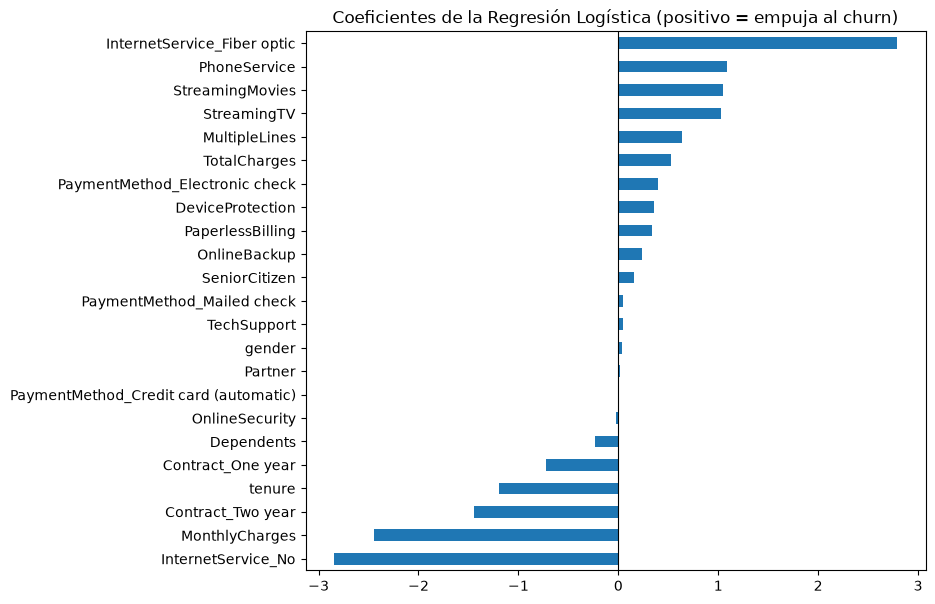

In [63]:
coeficientes = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values()
print(coeficientes.round(2))

plt.figure(figsize=(8, 7))
coeficientes.plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes de la Regresión Logística (positivo = empuja al churn)")
plt.show()


Aquí se extraen algunos análisis:

1. La fibra óptica es el factor que más empuja al churn (+2.79) y no tener internet el que más protege (-2.85).
2. Los contratos largos y la antigüedad protegen: 2 años (-1.45), 1  año (-0.73), meses como cliente (-1.19). esto tambien lo habia visto en DBSCAN
3. Los servicios de streaming, las múltiples líneas y la telefonía suman riesgo (alrededor de +1 cada uno).
4. El cheque electrónico (+0.40) y la facturación electrónica (+0.33) tambien suman. es mas o menos lo que tenía en el EDA.
5. MonthlyCharges: da negativo (-2.45) cuando el EDA decía que los que pagan más se van más. esto puede ser porque el cargo mensual es practicamente la suma de los servicios contratados, así que cuando el modelo ya sabe qué servicios tiene el cliente, el cobro mensual por sí solo no agrega riesgo. El riesgo lo ponen los servicios (sobre todo la fibra), no el precio en sí

Ahora juntaré el modelo con la segmentación: le paso el modelo a toda la base y comparo la probabilidad media de churn que le asigna a cada segmento de kmeans con el churn real de cada uno.

In [64]:
#le paso el modelo a toda la base (escalando las numéricas con el mismo scaler del train)
X_all = X.copy()
X_all[numeric_cols] = scaler.transform(X_all[numeric_cols])
df["prob_churn"] = log_reg.predict_proba(X_all)[:, 1]

print("Probabilidad media de churn que asigna el modelo a cada segmento (%):")
print((df.groupby("cluster_kmeans")["prob_churn"].mean()*100).round(1))
print()
print("Churn real de cada segmento (%):")
print((df.groupby("cluster_kmeans")["Churn"].mean()*100).round(1))


Probabilidad media de churn que asigna el modelo a cada segmento (%):
cluster_kmeans
0     2.3
1    36.8
2    78.3
3    25.4
4    51.5
5    10.1
Name: prob_churn, dtype: float64

Churn real de cada segmento (%):
cluster_kmeans
0     1.2
1    19.6
2    58.4
3    11.9
4    29.9
5     5.4
Name: Churn, dtype: Float64


Aquí se extraen algunos análisis:

1. El ranking del modelo coincide exacto con el ranking del churn real (2 > 4 > 1 > 3 > 5 > 0). El modelo y la segmentación dicen el mismo ranking de churn.
2. El segmento más propenso a irse es "Fibra de alto riesgo" (k 2): el modelo le asigna una probabilidad media de 78.3% y su churn real es 58.4%.
3. luego viene "DSL nuevos sin compromiso" (51.5% según el modelo, 29.9% real) que comparte el mes a mes y la poca antigüedad, pero el DSL no castiga como la fibra.
4. al final está "Leales sin internet" (2.3% y 1.2%)
5. es importante aclarar porqué el modelo tiene tanto churn predicho. Es por el balanceo de clases. el modelo prefiere predecir fp a fn. para comparar segmentos sirve el orden, no el número exacto de cada prediccion vs real.

**El perfil del cliente con mayor riesgo de churn en NexoTel es el de "Fibra de alto riesgo"**:<br><br> cliente nuevo, con fibra óptica, contrato mes a mes y boleta alta.

### Recomendaciones para NexoTel (4.2)

campaña de migración a contrato de 1 año para "Fibra de alto riesgo".

- Se podría ofrecer un descuento temporal (por ejemplo, un % de la boleta los primeros 6 meses) a cambio de firmar contrato de 1 año. además retener a uno de estos vale más que retener a uno de los segmentos baratos, así que el descuento se paga a largo plazo

programa de acompañamiento en los primeros 3 meses.

- contacto proactivo durante el primer mes y atencion al cliente preferente hasta el mes 3.
- Esto sería para todo cliente nuevo con prioridad para los que entran con fibra + contrato mes a mes
- Es más barato acompañar 3 meses que recuperar a un cliente perdido.

¿Por que todo esto puede funcionar?
- porque según los análisis es mucho menos probable que una persona se vaya una vez pasa la barrera de contrato mes a mes